# IV.2.4 — Spatial & Temporal Normalization Analysis

This notebook visualizes the **before vs. after effect** of each normalization step
applied in the preprocessing pipeline, as evidence that the spatial and temporal
problems identified in IV.2.2 and IV.2.3 are resolved.

Three normalization stages:
1. **IV.2.4.1 — Spatial Normalization** (`spatial_normalize`) → coordinate centering per body part
2. **IV.2.4.2 — Missing Keypoint Reconstruction** (`missing_keypoint_reconstruction`) → linear interpolation of [0,0] noise
3. **IV.2.4.3 — Temporal Normalization** (`temporal_normalize`) → fixed-length resampling

---

In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from collections import defaultdict
from scipy.interpolate import interp1d
import os

# ── Paper-style global rcParams (consistent with spatial_analysis.ipynb) ──────
plt.rcParams.update({
    'figure.facecolor'   : 'white',
    'axes.facecolor'     : 'white',
    'axes.edgecolor'     : '#333333',
    'axes.linewidth'     : 0.8,
    'axes.grid'          : False,
    'font.family'        : 'serif',
    'font.serif'         : ['Times New Roman', 'DejaVu Serif'],
    'font.size'          : 10,
    'axes.titlesize'     : 10,
    'axes.titleweight'   : 'bold',
    'axes.labelsize'     : 9,
    'xtick.labelsize'    : 8,
    'ytick.labelsize'    : 8,
    'legend.fontsize'    : 9,
    'figure.titlesize'   : 11,
    'figure.titleweight' : 'bold',
    'savefig.dpi'        : 300,
    'savefig.bbox'       : 'tight',
    'savefig.pad_inches' : 0.05,
})

# ── Color palette (consistent with spatial_analysis.ipynb) ────────────────────
C_LH     = '#2166AC'
C_RH     = '#D6604D'
C_EDGE   = '#555555'
C_NOISE  = '#B2182B'
C_MED    = '#B2182B'
C_BEFORE = '#AAAAAA'   # Gray  — raw/before
C_AFTER  = '#2166AC'   # Blue  — after normalization
SIGNER_COLORS = ['#2166AC', '#D6604D', '#1A9641', '#7B2D8B', '#E08214', '#555555']

# ── Hand skeleton edges ───────────────────────────────────────────────────────
HAND_EDGES = [
    (0,1),(1,2),(2,3),(3,4),
    (0,5),(5,6),(6,7),(7,8),
    (0,9),(9,10),(10,11),(11,12),
    (0,13),(13,14),(14,15),(15,16),
    (0,17),(17,18),(18,19),(19,20),
    (5,9),(9,13),(13,17)
]
CONNECTIONS = [(u,v) for u,v in HAND_EDGES] + [(u+21,v+21) for u,v in HAND_EDGES]
IDX_LH   = np.arange(0, 21)
IDX_RH   = np.arange(21, 42)
IDX_HAND = np.arange(0, 42)

OUTPUT_DIR = '../data/results'
os.makedirs(OUTPUT_DIR, exist_ok=True)
print('Configuration loaded.')

Configuration loaded.


## 0. Load Data


In [2]:
# ── CONFIGURATION — adjust path to match your directory structure ─────────────
PICKLE_FILE = '../data/pickle/pose_bisindo.pkl'

with open(PICKLE_FILE, 'rb') as f:
    data = pickle.load(f)

video_ids = list(data.keys())
speakers  = sorted(set(v.split('_')[0] for v in video_ids))
print(f'Total videos : {len(video_ids)}')
print(f'Signers      : {speakers}')

# Keypoint layout (86 points):
# [0:21]  = Left Hand  | [21:42] = Right Hand
# [42:61] = Mouth      | [61:86] = Pose/Body
K_TOTAL = 86

Total videos : 750
Signers      : ['P01', 'P02', 'P03', 'P04', 'P05']


## 1. Normalization Functions

Implementations of the three normalization stages from the preprocessing pipeline.


In [4]:
# ── spatial_normalize() ───────────────────────────────────────────────────────
# Source: baseline pipeline (adapted)
# Centralizes each body part around its reference keypoint.

import numpy as np

def spatial_scale_normalize(
    kp_xy,
    left_wrist_idx=0,
    left_middle_idx=12,
    right_wrist_idx=21,
    right_middle_idx=33,
    eps=1e-8
):
    """
    kp_xy : (T,42,2)

    0-20   = left hand
    21-41  = right hand
    """

    out = kp_xy.copy()

    # ---------- LEFT HAND ----------

    left_wrist = out[:, left_wrist_idx]

    left_scale = np.linalg.norm(
        out[:, left_middle_idx] - left_wrist,
        axis=1,
        keepdims=True
    )

    left_scale = np.maximum(left_scale, eps)

    out[:, :21] = (
        out[:, :21] - left_wrist[:, None, :]
    ) / left_scale[:, None, :]

    # ---------- RIGHT HAND ----------

    right_wrist = out[:, right_wrist_idx]

    right_scale = np.linalg.norm(
        out[:, right_middle_idx] - right_wrist,
        axis=1,
        keepdims=True
    )

    right_scale = np.maximum(right_scale, eps)

    out[:, 21:42] = (
        out[:, 21:42] - right_wrist[:, None, :]
    ) / right_scale[:, None, :]

    return out


# ── missing_keypoint_reconstruction() ────────────────────────────────────────
# Linear interpolation of [0,0] frames per keypoint.

def missing_keypoint_reconstruction(kp_xy):
    """
    kp_xy : np.ndarray (T, K, 2)
    Returns reconstructed (T, K, 2)
    """
    result = kp_xy.copy().astype(float)
    T, K, _ = result.shape

    for k in range(K):
        coords     = result[:, k, :]                          # (T, 2)
        valid_mask = ~((coords[:, 0] == 0) & (coords[:, 1] == 0))
        valid_idx  = np.where(valid_mask)[0]

        if len(valid_idx) == 0:
            continue                                           # all missing — skip

        for t in range(T):
            if valid_mask[t]:
                continue

            prev_arr = valid_idx[valid_idx < t]
            next_arr = valid_idx[valid_idx > t]

            if len(prev_arr) and len(next_arr):
                p, n  = prev_arr[-1], next_arr[0]
                alpha = (t - p) / (n - p)
                coords[t] = (1 - alpha) * coords[p] + alpha * coords[n]
            elif len(prev_arr):
                coords[t] = coords[prev_arr[-1]]
            elif len(next_arr):
                coords[t] = coords[next_arr[0]]

        result[:, k, :] = coords

    return result


# ── temporal_normalize() ──────────────────────────────────────────────────────
# Resamples sequence to a fixed target length via linear interpolation.

def temporal_normalize(kp_xy, target_length):
    """
    kp_xy         : np.ndarray (T, K, 2)
    target_length : int
    Returns resampled (target_length, K, 2)
    """
    T, K, F = kp_xy.shape
    if T == target_length:
        return kp_xy.copy()

    orig_idx = np.linspace(0, T - 1, T)
    new_idx  = np.linspace(0, T - 1, target_length)

    result = np.zeros((target_length, K, F), dtype=kp_xy.dtype)
    for k in range(K):
        for f in range(F):
            fn = interp1d(orig_idx, kp_xy[:, k, f], kind='linear')
            result[:, k, f] = fn(new_idx)

    return result


print('Normalization functions defined.')

Normalization functions defined.


---
## IV.2.4.1 — Spatial Normalization

- **Fig A** — Skeleton side-by-side: raw vs. normalized (one signer, one frame)


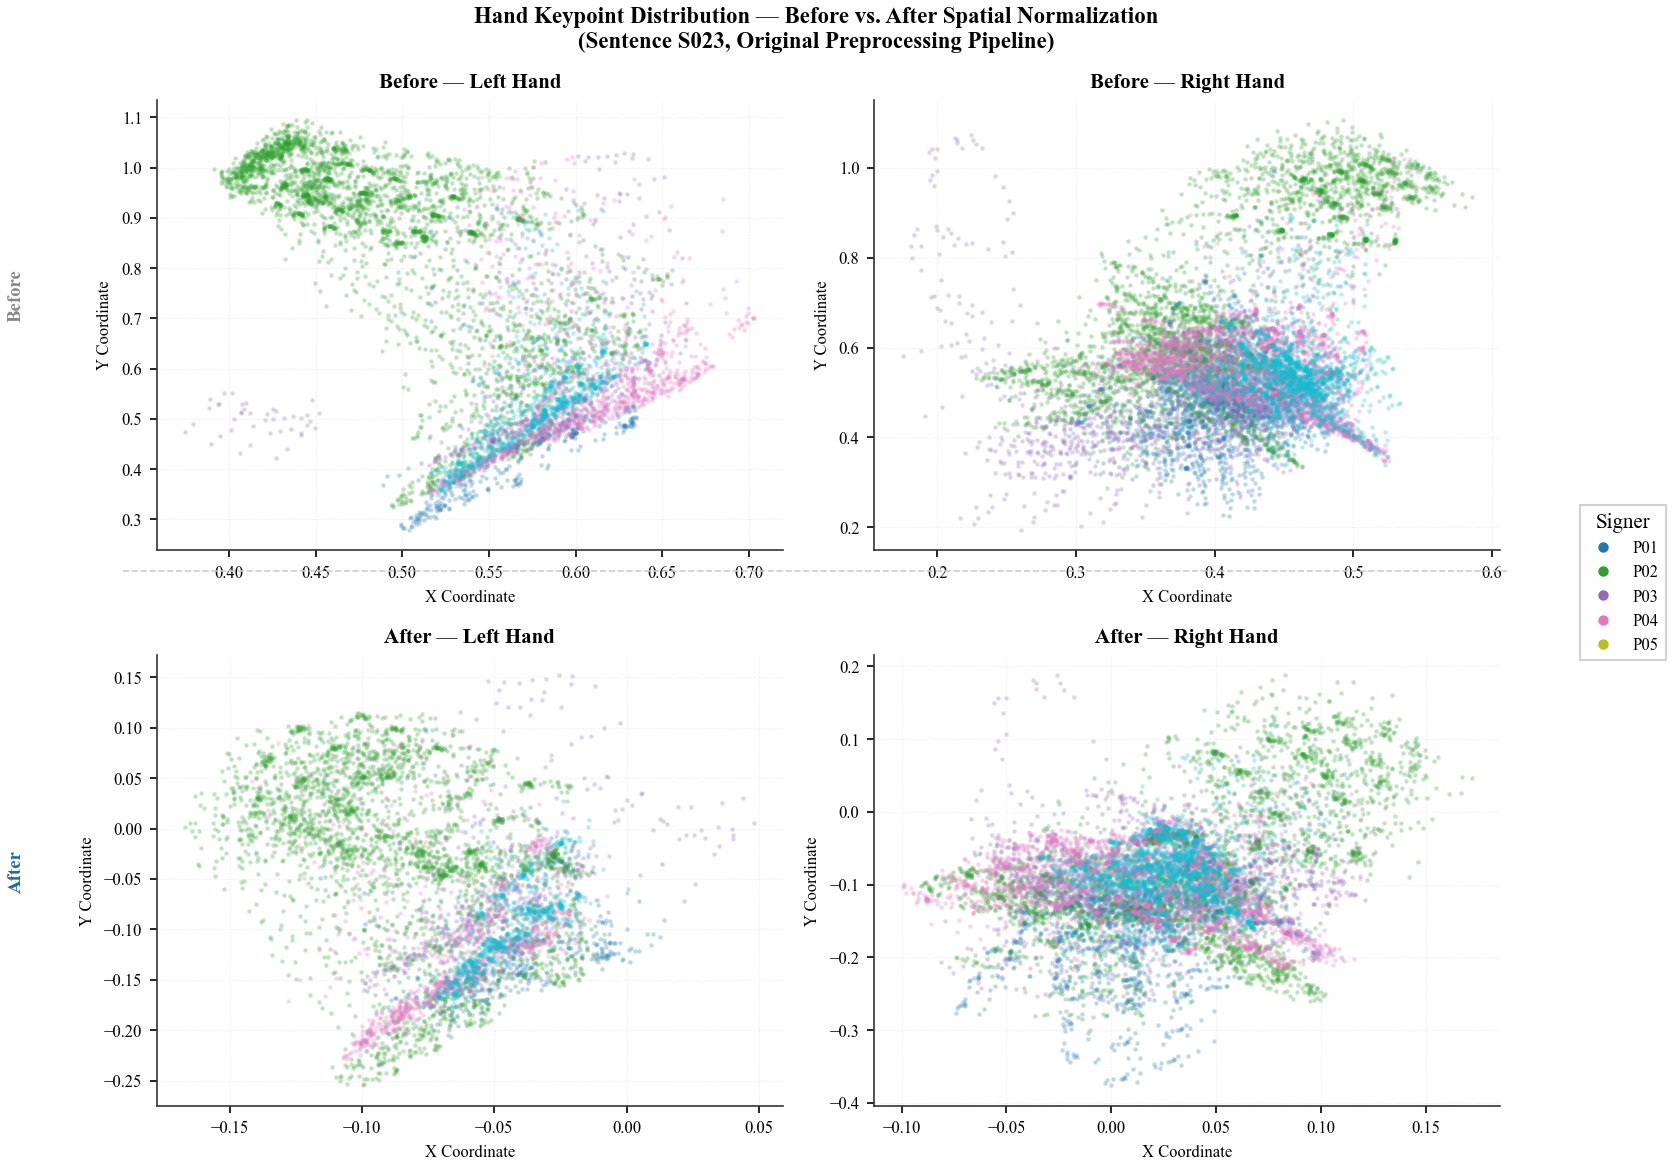

[SAVED] ../data/results\norm_A_spatial_scatter_before_after.png


In [ ]:
# ── Fig A: Scatter Overlay — Before vs. After Spatial Normalization ─────────
# IMPORTANT:
# This version uses the ORIGINAL spatial_normalize() preprocessing function
# instead of manual wrist subtraction.

# ── CONFIGURATION ────────────────────────────────────────────────────────────

TARGET_SEQUENCE = 'S023'
TARGET_REP      = 'R01'

# Spatial normalization configuration
USED_PART  = ['hand21']
SPLIT      = [21, 42]
NORM_POINT = [0, 21]

# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(
    2,
    2,
    figsize=(11, 8),
    dpi=150
)

plot_configs = [

    (axes[0,0], IDX_LH, 'Before — Left Hand',  False),
    (axes[0,1], IDX_RH, 'Before — Right Hand', False),

    (axes[1,0], IDX_LH, 'After — Left Hand',   True),
    (axes[1,1], IDX_RH, 'After — Right Hand',  True),
]

colors_sp = plt.cm.tab10(
    np.linspace(0, 0.9, len(speakers))
)

for ax, idx_part, title, do_norm in plot_configs:

    for sp, color in zip(speakers, colors_sp):

        sp_vids = sorted([

            v for v in video_ids
            if v.startswith(sp)
            and TARGET_SEQUENCE in v
            and f'_{TARGET_REP}' in v
        ])

        if not sp_vids:
            continue

        # ── LOAD RAW KEYPOINTS ─────────────────────────────────────────────

        kp = data[
            sp_vids[0]
        ]['keypoints'].copy().astype(float)

        # ── APPLY ORIGINAL SPATIAL NORMALIZATION ──────────────────────────

        if do_norm:

            kp_proc = spatial_normalize(

                kp.copy(),

                norm_div=1.0,

                used_part=USED_PART,

                split=SPLIT,

                norm_point=NORM_POINT
            )

        else:

            kp_proc = kp.copy()

        # ── SELECT TARGET PART ────────────────────────────────────────────

        pts = kp_proc[:, idx_part, :]

        # ── REMOVE INVALID POINTS ─────────────────────────────────────────

        valid = ~(
            (pts[:,:,0] == 0) &
            (pts[:,:,1] == 0)
        )

        # ── SCATTER PLOT ──────────────────────────────────────────────────

        ax.scatter(

            pts[:,:,0][valid],
            pts[:,:,1][valid],

            s=2.0,
            alpha=0.18,

            color=color,

            label=sp,

            rasterized=True
        )

    # ── TITLE ──────────────────────────────────────────────────────────────

    ax.set_title(
        title,
        fontsize=10,
        fontweight='bold'
    )

    # ── AXIS LABELS ───────────────────────────────────────────────────────

    ax.set_xlabel(
        'X Coordinate',
        fontsize=8
    )

    ax.set_ylabel(
        'Y Coordinate',
        fontsize=8
    )

    # ── GRID ───────────────────────────────────────────────────────────────

    ax.grid(
        True,
        linestyle=':',
        linewidth=0.5,
        alpha=0.25
    )

    # ── CLEAN STYLE ───────────────────────────────────────────────────────

    for spine in ['top', 'right']:

        ax.spines[spine].set_visible(False)

# ── DIVIDER LINE ─────────────────────────────────────────────────────────────

fig.add_artist(

    plt.Line2D(

        [0.08, 0.92],
        [0.51, 0.51],

        transform=fig.transFigure,

        color='#cccccc',
        linewidth=0.8,
        linestyle='--'
    )
)

# ── ROW LABELS ───────────────────────────────────────────────────────────────

fig.text(

    0.01,
    0.74,

    'Before',

    va='center',
    rotation=90,

    fontsize=9,
    fontweight='bold',

    color='#888888'
)

fig.text(

    0.01,
    0.26,

    'After',

    va='center',
    rotation=90,

    fontsize=9,
    fontweight='bold',

    color='#2166AC'
)

# ── LEGEND ───────────────────────────────────────────────────────────────────

handles = [

    Line2D(

        [0],[0],

        marker='o',
        color='w',

        markerfacecolor=plt.cm.tab10(
            i / len(speakers)
        ),

        markersize=6,

        label=sp

    )

    for i, sp in enumerate(speakers)
]

fig.legend(

    handles=handles,

    title='Signer',

    loc='center right',

    bbox_to_anchor=(1.02, 0.5),

    frameon=True,
    framealpha=0.9,

    edgecolor='#cccccc',

    fancybox=False,

    fontsize=8
)

# ── MAIN TITLE ───────────────────────────────────────────────────────────────

plt.suptitle(

    'Hand Keypoint Distribution — Before vs. After Spatial Normalization\n'
    f'(Sentence {TARGET_SEQUENCE}, Original Preprocessing Pipeline)',

    fontsize=11,
    fontweight='bold'
)

# ── LAYOUT ───────────────────────────────────────────────────────────────────

plt.tight_layout(
    rect=[0.04, 0, 0.93, 1]
)

# ── SAVE ─────────────────────────────────────────────────────────────────────

save_path = os.path.join(
    OUTPUT_DIR,
    'norm_A_spatial_scatter_before_after.png'
)

plt.savefig(
    save_path,
    dpi=600
)

plt.show()

print(f'[SAVED] {save_path}')


LEFT WRIST
Before : 0.2622
After  : 0.0000

RIGHT WRIST
Before : 0.1959
After  : 0.0000


C:\Users\IKAJTK\AppData\Local\Temp\ipykernel_21572\1046797649.py:307: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(


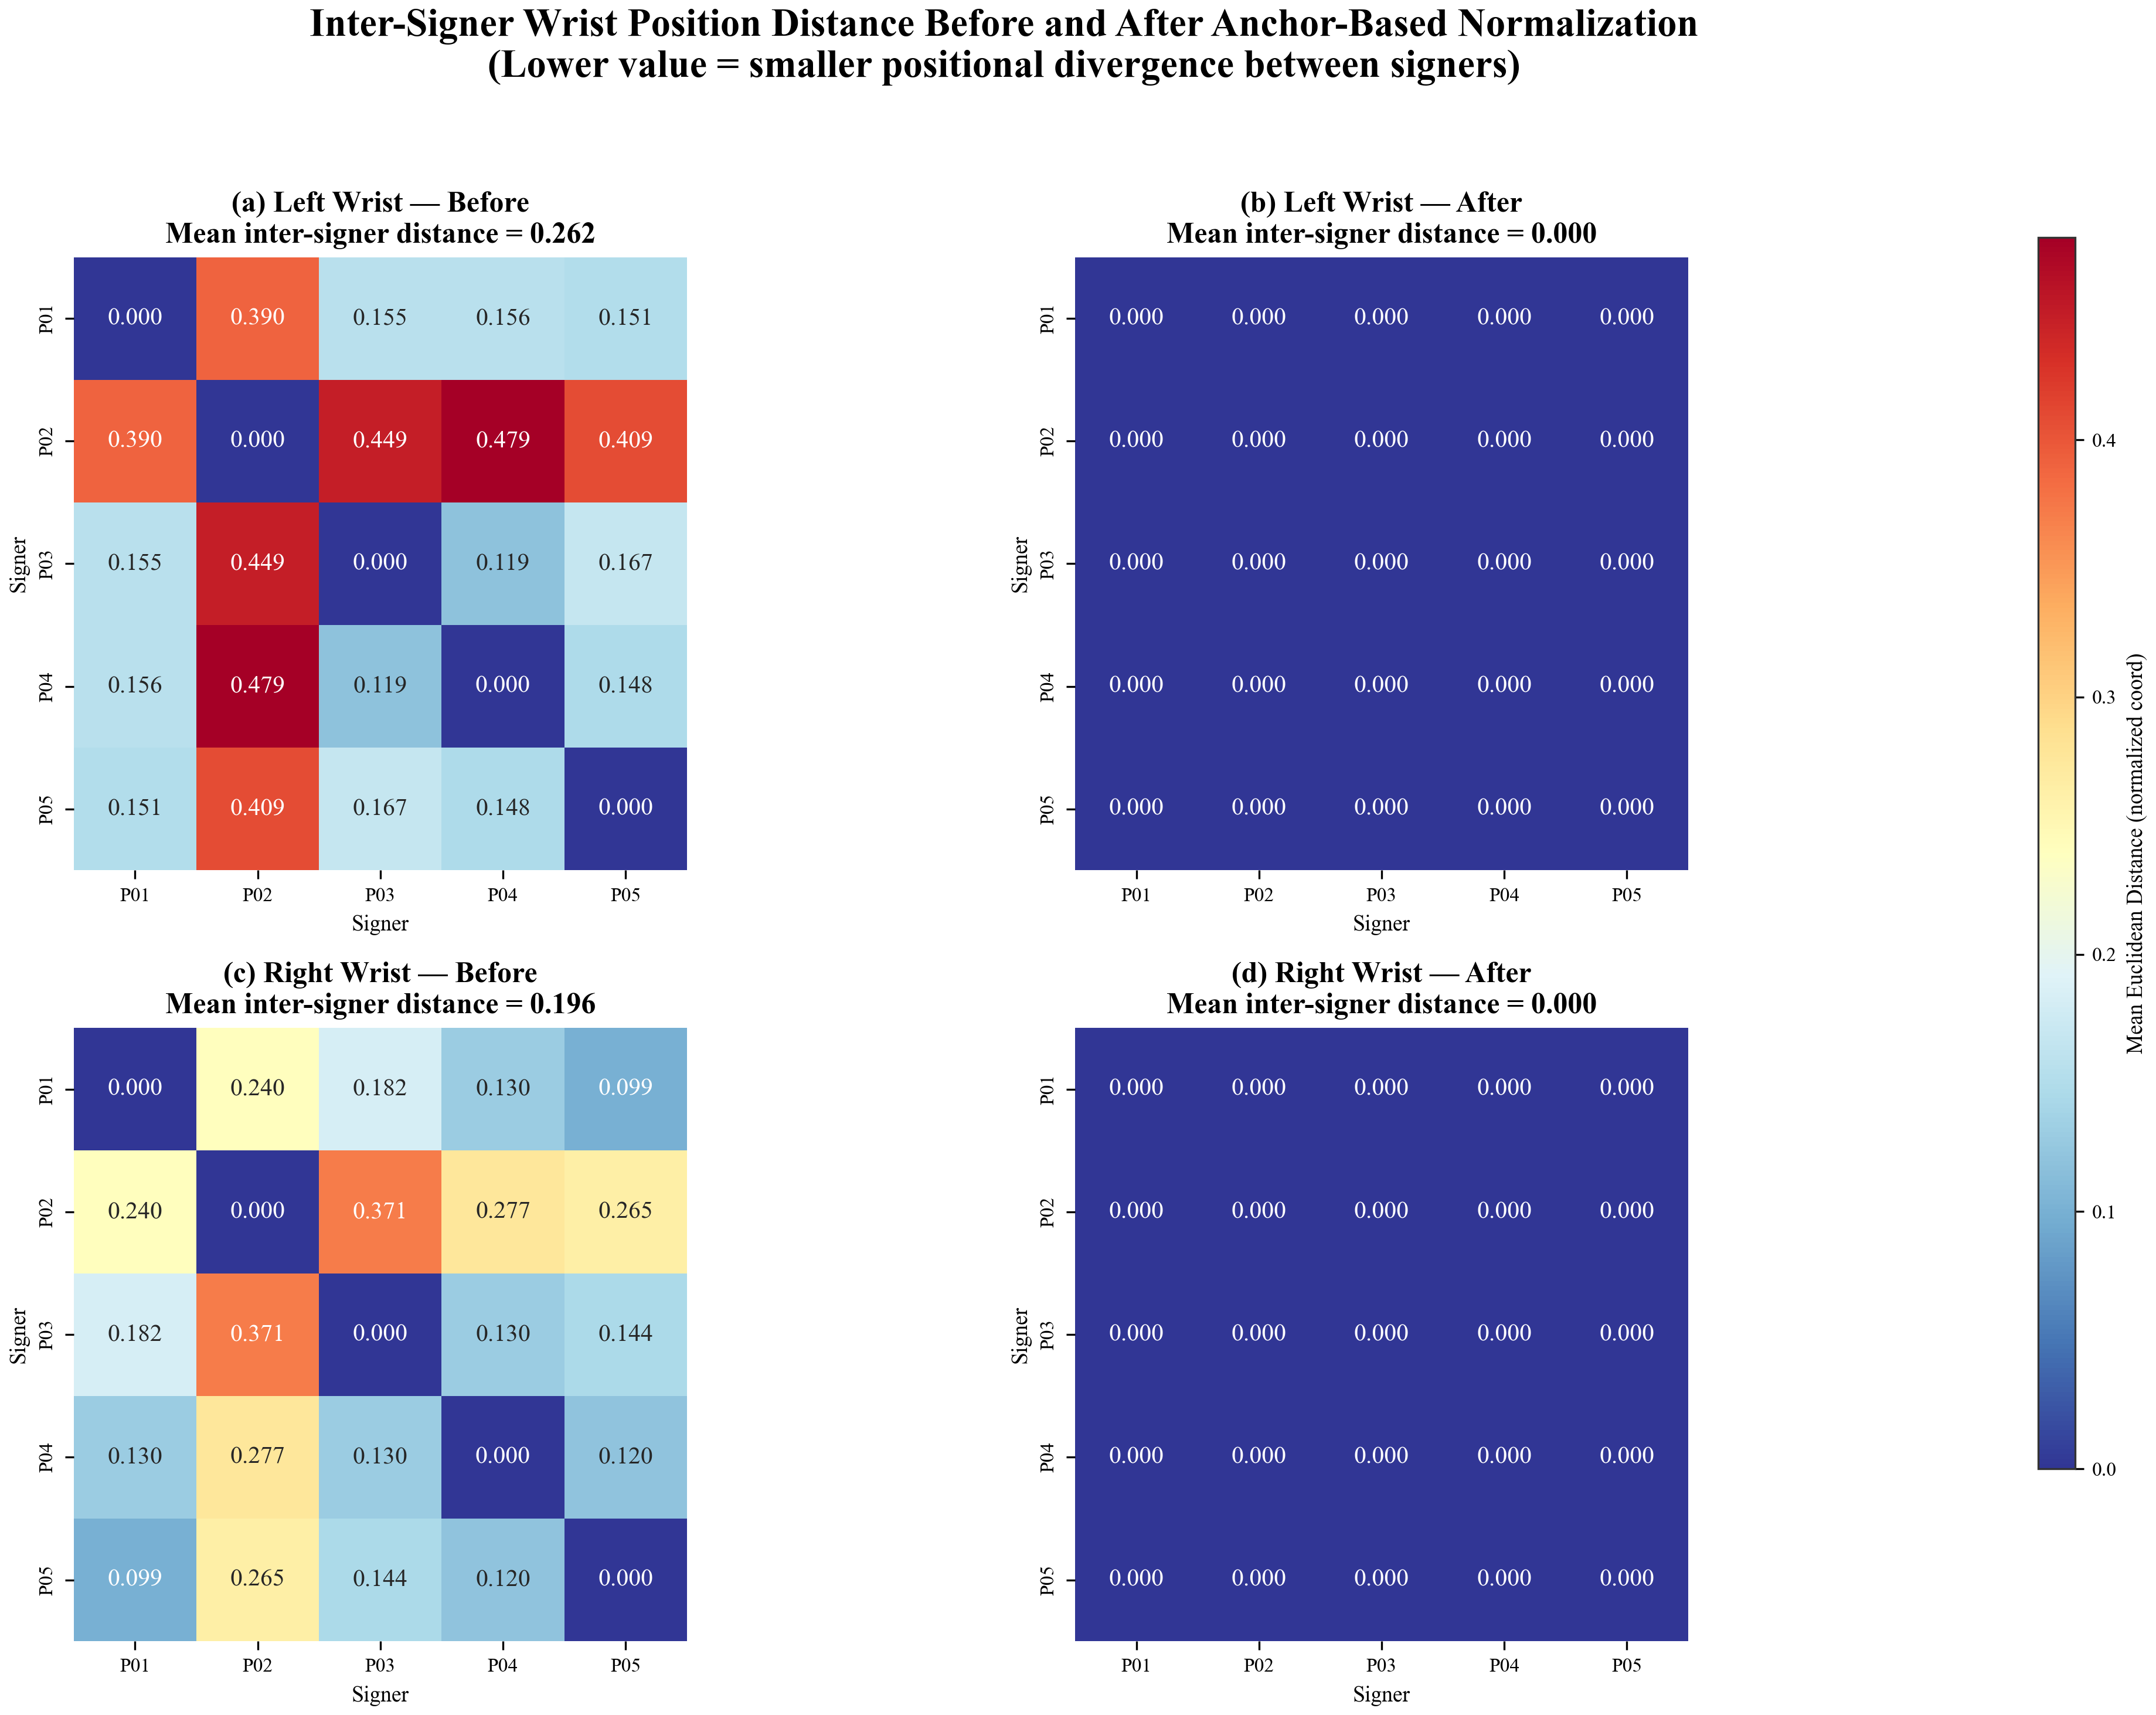

In [ ]:
# ============================================================
# FIGURE IV.35
# Inter-Signer Wrist Position Distance
# Before vs After Anchor-Based Normalization
# (same methodology as IV.3.1.1)
# ============================================================

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import combinations

# ------------------------------------------------------------
# Sentence discovery
# ------------------------------------------------------------

sentence_labels = sorted(
    set(v.split('_')[1] for v in video_ids)
)

# ------------------------------------------------------------
# Build sentence-level centroid data
# ------------------------------------------------------------

def get_sentence_centroids(normalized=False):

    sentence_data = {}

    for sentence in sentence_labels:

        sentence_data[sentence] = {}

        for sp in speakers:

            vids = [
                v for v in video_ids
                if v.startswith(sp)
                and sentence in v
            ]

            if len(vids) == 0:
                continue

            lh_all = []
            rh_all = []

            for vid in vids:

                kp = data[vid]['keypoints'].astype(float)

                if normalized:
                    kp = spatial_scale_normalize(
                        kp.copy()
                    )

                # wrist centroid per video
                lh_all.append(
                    np.nanmean(
                        kp[:, 0, :],
                        axis=0
                    )
                )

                rh_all.append(
                    np.nanmean(
                        kp[:, 21, :],
                        axis=0
                    )
                )

            sentence_data[sentence][sp] = {
                'LH': np.mean(lh_all, axis=0),
                'RH': np.mean(rh_all, axis=0)
            }

    return sentence_data


# ------------------------------------------------------------
# Build inter-signer matrix
# ------------------------------------------------------------

def build_inter_signer_matrix(
    sentence_data,
    hand='LH'
):

    n = len(speakers)

    mat = np.zeros((n, n))
    cnt = np.zeros((n, n))

    for sentence, signer_data in sentence_data.items():

        available = [
            s for s in speakers
            if s in signer_data
        ]

        for s1, s2 in combinations(
            available,
            2
        ):

            i = speakers.index(s1)
            j = speakers.index(s2)

            d = np.linalg.norm(
                signer_data[s1][hand]
                - signer_data[s2][hand]
            )

            mat[i, j] += d
            mat[j, i] += d

            cnt[i, j] += 1
            cnt[j, i] += 1

    valid = cnt > 0

    mat[valid] /= cnt[valid]

    return mat


# ------------------------------------------------------------
# Mean pairwise distance
# ------------------------------------------------------------

def mean_pairwise(mat):

    idx = np.triu_indices_from(
        mat,
        k=1
    )

    return mat[idx].mean()


# ------------------------------------------------------------
# Generate matrices
# ------------------------------------------------------------

raw_data = get_sentence_centroids(
    normalized=False
)

norm_data = get_sentence_centroids(
    normalized=True
)

lh_before = build_inter_signer_matrix(
    raw_data,
    hand='LH'
)

lh_after = build_inter_signer_matrix(
    norm_data,
    hand='LH'
)

rh_before = build_inter_signer_matrix(
    raw_data,
    hand='RH'
)

rh_after = build_inter_signer_matrix(
    norm_data,
    hand='RH'
)

# ------------------------------------------------------------
# Summary statistics
# ------------------------------------------------------------

lh_before_mean = mean_pairwise(
    lh_before
)

lh_after_mean = mean_pairwise(
    lh_after
)

rh_before_mean = mean_pairwise(
    rh_before
)

rh_after_mean = mean_pairwise(
    rh_after
)

print('\nLEFT WRIST')
print(f'Before : {lh_before_mean:.4f}')
print(f'After  : {lh_after_mean:.4f}')

print('\nRIGHT WRIST')
print(f'Before : {rh_before_mean:.4f}')
print(f'After  : {rh_after_mean:.4f}')

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

vmax = max(
    lh_before.max(),
    rh_before.max()
)

fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 10),
    dpi=300
)

heatmaps = [

    (
        lh_before,
        '(a) Left Wrist — Before\n'
        f'Mean inter-signer distance = {lh_before_mean:.3f}'
    ),

    (
        lh_after,
        '(b) Left Wrist — After\n'
        f'Mean inter-signer distance = {lh_after_mean:.3f}'
    ),

    (
        rh_before,
        '(c) Right Wrist — Before\n'
        f'Mean inter-signer distance = {rh_before_mean:.3f}'
    ),

    (
        rh_after,
        '(d) Right Wrist — After\n'
        f'Mean inter-signer distance = {rh_after_mean:.3f}'
    )
]

for ax, (mat, title) in zip(
    axes.flatten(),
    heatmaps
):

    sns.heatmap(
        mat,
        annot=True,
        fmt='.3f',
        cmap='RdYlBu_r',
        square=True,
        xticklabels=speakers,
        yticklabels=speakers,
        vmin=0,
        vmax=vmax,
        cbar=False,
        ax=ax
    )

    ax.set_title(
        title,
        fontsize=12,
        fontweight='bold'
    )

    ax.set_xlabel('Signer')
    ax.set_ylabel('Signer')

# ------------------------------------------------------------
# Shared colorbar
# ------------------------------------------------------------

cbar_ax = fig.add_axes(
    [0.92, 0.15, 0.015, 0.70]
)

sm = plt.cm.ScalarMappable(
    cmap='RdYlBu_r'
)

sm.set_clim(
    0,
    vmax
)

fig.colorbar(
    sm,
    cax=cbar_ax,
    label='Mean Euclidean Distance (normalized coord)'
)

plt.suptitle(
    'Inter-Signer Wrist Position Distance Before and After Anchor-Based Normalization\n'
    '(Lower value = smaller positional divergence between signers)',
    fontsize=16,
    fontweight='bold',
    y=0.98
)

plt.tight_layout(
    rect=[0, 0, 0.9, 0.95]
)

plt.show()


LEFT WRIST
Before : 0.2622
After  : 0.0000

RIGHT WRIST
Before : 0.1959
After  : 0.0000


C:\Users\IKAJTK\AppData\Local\Temp\ipykernel_21572\1046797649.py:307: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(


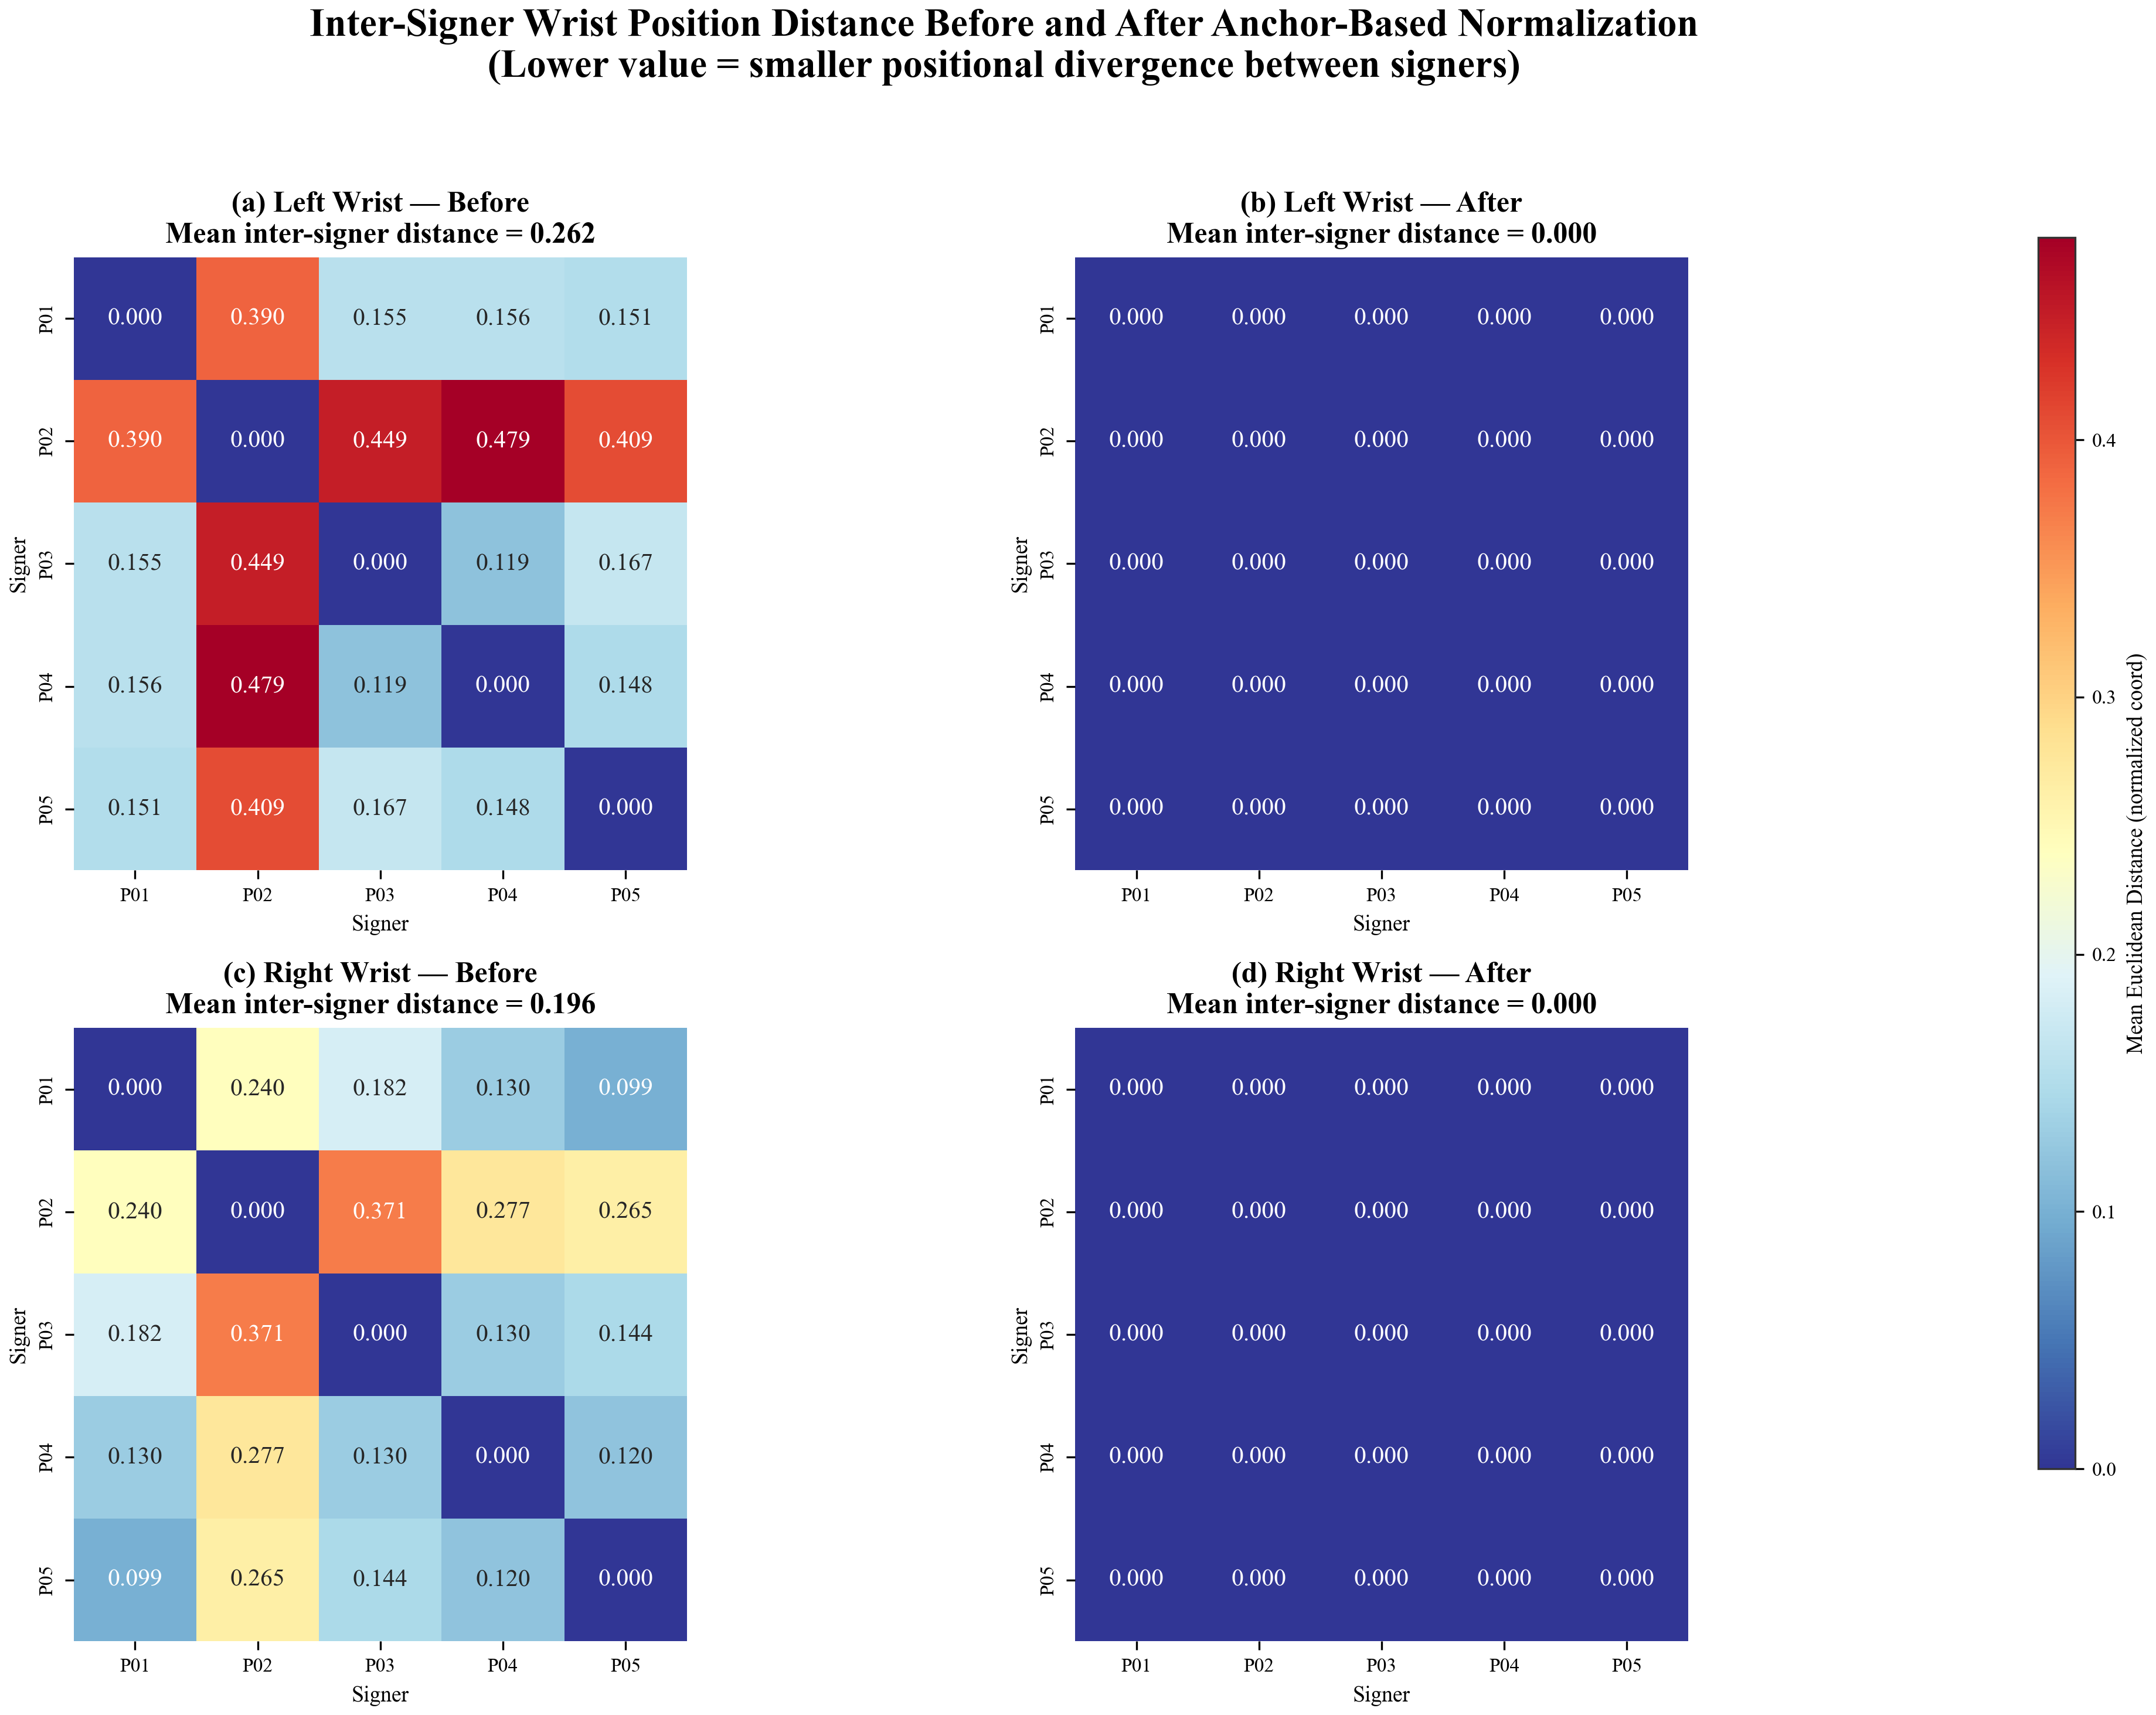

In [ ]:
# ============================================================
# FIGURE IV.35
# Inter-Signer Wrist Position Distance
# Before vs After Anchor-Based Normalization
# (same methodology as IV.3.1.1)
# ============================================================

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import combinations

# ------------------------------------------------------------
# Sentence discovery
# ------------------------------------------------------------

sentence_labels = sorted(
    list(
        set(
            '_'.join(v.split('_')[1:])
            for v in video_ids
        )
    )
)

# ------------------------------------------------------------
# Build sentence-level centroid data
# ------------------------------------------------------------

def get_sentence_centroids(normalized=False):

    sentence_data = {}

    for sentence in sentence_labels:

        sentence_data[sentence] = {}

        for sp in speakers:

            vids = [
                v for v in video_ids
                if v.startswith(sp)
                and sentence in v
            ]

            if len(vids) == 0:
                continue

            lh_all = []
            rh_all = []

            for vid in vids:

                kp = data[vid]['keypoints'].astype(float)

                if normalized:
                    kp = spatial_scale_normalize(
                        kp.copy()
                    )

                # wrist centroid per video
                lh_all.append(
                    np.nanmean(
                        kp[:, 0, :],
                        axis=0
                    )
                )

                rh_all.append(
                    np.nanmean(
                        kp[:, 21, :],
                        axis=0
                    )
                )

            sentence_data[sentence][sp] = {
                'LH': np.mean(lh_all, axis=0),
                'RH': np.mean(rh_all, axis=0)
            }

    return sentence_data


# ------------------------------------------------------------
# Build inter-signer matrix
# ------------------------------------------------------------

def build_inter_signer_matrix(
    sentence_data,
    hand='LH'
):

    n = len(speakers)

    mat = np.zeros((n, n))
    cnt = np.zeros((n, n))

    for sentence, signer_data in sentence_data.items():

        available = [
            s for s in speakers
            if s in signer_data
        ]

        for s1, s2 in combinations(
            available,
            2
        ):

            i = speakers.index(s1)
            j = speakers.index(s2)

            d = np.linalg.norm(
                signer_data[s1][hand]
                - signer_data[s2][hand]
            )

            mat[i, j] += d
            mat[j, i] += d

            cnt[i, j] += 1
            cnt[j, i] += 1

    valid = cnt > 0

    mat[valid] /= cnt[valid]

    return mat


# ------------------------------------------------------------
# Mean pairwise distance
# ------------------------------------------------------------

def mean_pairwise(mat):

    idx = np.triu_indices_from(
        mat,
        k=1
    )

    return mat[idx].mean()


# ------------------------------------------------------------
# Generate matrices
# ------------------------------------------------------------

raw_data = get_sentence_centroids(
    normalized=False
)

norm_data = get_sentence_centroids(
    normalized=True
)

lh_before = build_inter_signer_matrix(
    raw_data,
    hand='LH'
)

lh_after = build_inter_signer_matrix(
    norm_data,
    hand='LH'
)

rh_before = build_inter_signer_matrix(
    raw_data,
    hand='RH'
)

rh_after = build_inter_signer_matrix(
    norm_data,
    hand='RH'
)

# ------------------------------------------------------------
# Summary statistics
# ------------------------------------------------------------

lh_before_mean = mean_pairwise(
    lh_before
)

lh_after_mean = mean_pairwise(
    lh_after
)

rh_before_mean = mean_pairwise(
    rh_before
)

rh_after_mean = mean_pairwise(
    rh_after
)

print('\nLEFT WRIST')
print(f'Before : {lh_before_mean:.4f}')
print(f'After  : {lh_after_mean:.4f}')

print('\nRIGHT WRIST')
print(f'Before : {rh_before_mean:.4f}')
print(f'After  : {rh_after_mean:.4f}')

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

vmax = max(
    lh_before.max(),
    rh_before.max()
)

fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 10),
    dpi=300
)

heatmaps = [

    (
        lh_before,
        '(a) Left Wrist — Before\n'
        f'Mean inter-signer distance = {lh_before_mean:.3f}'
    ),

    (
        lh_after,
        '(b) Left Wrist — After\n'
        f'Mean inter-signer distance = {lh_after_mean:.3f}'
    ),

    (
        rh_before,
        '(c) Right Wrist — Before\n'
        f'Mean inter-signer distance = {rh_before_mean:.3f}'
    ),

    (
        rh_after,
        '(d) Right Wrist — After\n'
        f'Mean inter-signer distance = {rh_after_mean:.3f}'
    )
]

for ax, (mat, title) in zip(
    axes.flatten(),
    heatmaps
):

    sns.heatmap(
        mat,
        annot=True,
        fmt='.3f',
        cmap='RdYlBu_r',
        square=True,
        xticklabels=speakers,
        yticklabels=speakers,
        vmin=0,
        vmax=vmax,
        cbar=False,
        ax=ax
    )

    ax.set_title(
        title,
        fontsize=12,
        fontweight='bold'
    )

    ax.set_xlabel('Signer')
    ax.set_ylabel('Signer')

# ------------------------------------------------------------
# Shared colorbar
# ------------------------------------------------------------

cbar_ax = fig.add_axes(
    [0.92, 0.15, 0.015, 0.70]
)

sm = plt.cm.ScalarMappable(
    cmap='RdYlBu_r'
)

sm.set_clim(
    0,
    vmax
)

fig.colorbar(
    sm,
    cax=cbar_ax,
    label='Mean Euclidean Distance (normalized coord)'
)

plt.suptitle(
    'Inter-Signer Wrist Position Distance Before and After Anchor-Based Normalization\n'
    '(Lower value = smaller positional divergence between signers)',
    fontsize=16,
    fontweight='bold',
    y=0.98
)

plt.tight_layout(
    rect=[0, 0, 0.9, 0.95]
)

plt.show()

---
## IV.2.4.2 — Missing Keypoint Reconstruction

Two visualizations:
- **Fig C** — Coordinate trajectory before vs. after interpolation (one keypoint, one video)
- **Fig D** — Noise rate per keypoint before vs. after reconstruction


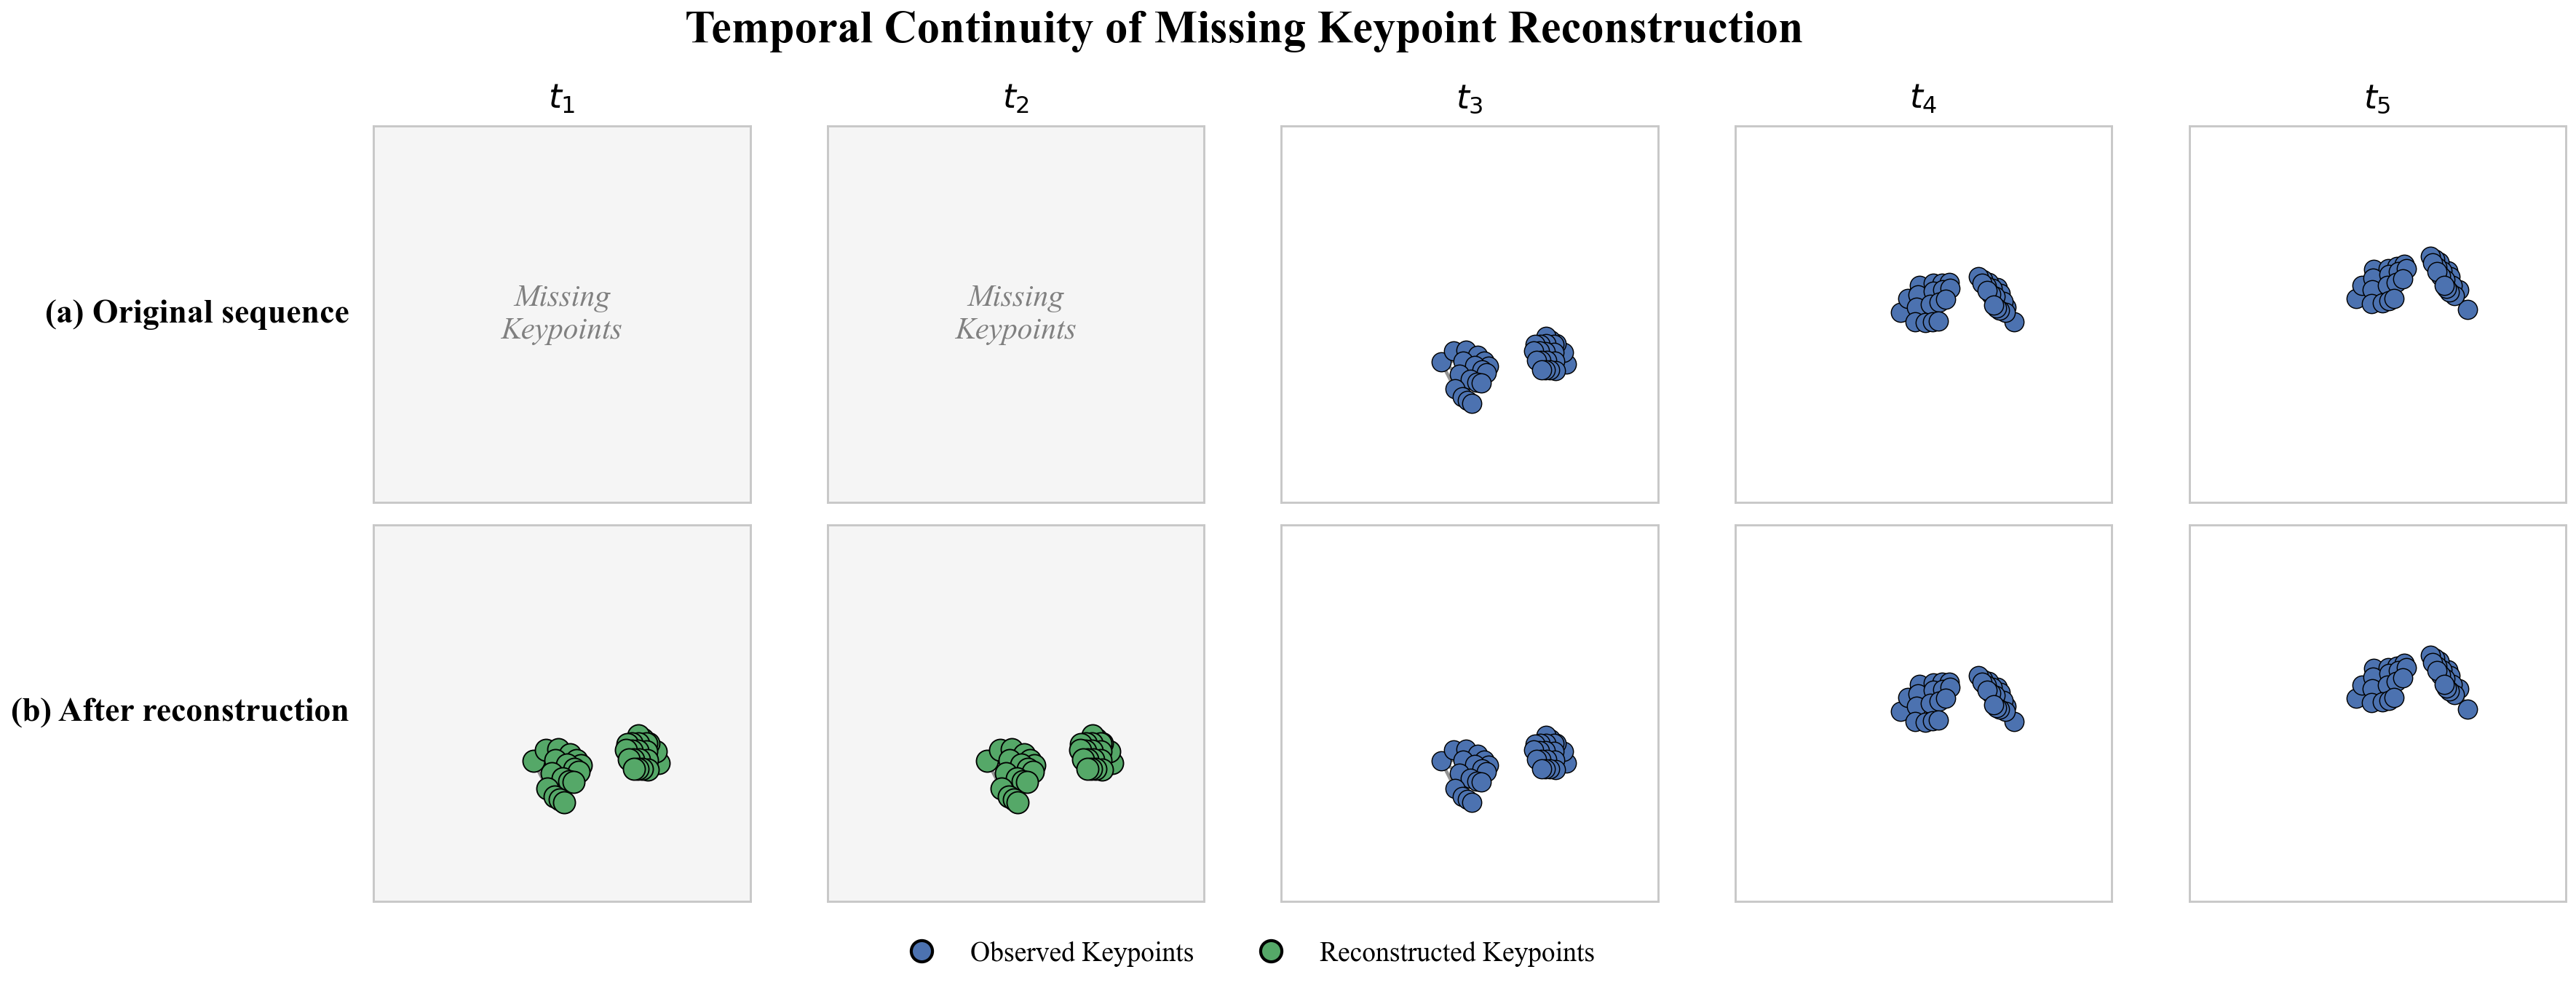

[SAVED] ../data/results\publication_temporal_reconstruction_final.png


In [57]:
# ── PUBLICATION-STYLE TEMPORAL VISUALIZATION ───────────────────────────────
# Goal:
# Visualize temporal continuity before vs after missing-keypoint reconstruction
# with cleaner semantic visualization for publication figures.

import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ── CONFIG ─────────────────────────────────────────────────────────────────

TARGET_VIDEO = 'P03_S023_R01'

START_FRAME = 42
N_FRAMES    = 5

SAVE_NAME = 'publication_temporal_reconstruction_final.png'

# ── LOAD ───────────────────────────────────────────────────────────────────

kp_raw = data[TARGET_VIDEO]['keypoints'].copy().astype(float)

kp_rec = missing_keypoint_reconstruction(
    kp_raw.copy()
)

# ── HAND INDICES ───────────────────────────────────────────────────────────

IDX_LH = np.arange(0, 21)
IDX_RH = np.arange(21, 42)

# ── HAND CONNECTIONS ───────────────────────────────────────────────────────

HAND_CONNECTIONS = [

    (0,1),(1,2),(2,3),(3,4),

    (0,5),(5,6),(6,7),(7,8),

    (0,9),(9,10),(10,11),(11,12),

    (0,13),(13,14),(14,15),(15,16),

    (0,17),(17,18),(18,19),(19,20)
]

# ── COLORS ─────────────────────────────────────────────────────────────────

C_OBSERVED = '#4C72B0'
C_RECON    = '#55A868'

C_MISSING  = '#2F2F2F'
C_EDGE     = '#808080'

C_BG_MISS  = '#F5F5F5'

# ── FIGURE ─────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(
    2,
    N_FRAMES,
    figsize=(12.5, 4.8),
    dpi=300
)

# ── GLOBAL AXIS RANGE ─────────────────────────────────────────────────────

all_pts = np.concatenate([

    kp_raw[:, :42, :2].reshape(-1, 2),
    kp_rec[:, :42, :2].reshape(-1, 2)

], axis=0)

valid = ~(
    (all_pts[:,0] == 0) &
    (all_pts[:,1] == 0)
)

all_pts = all_pts[valid]

xmin, xmax = np.percentile(all_pts[:,0], [1, 99])
ymin, ymax = np.percentile(-all_pts[:,1], [1, 99])

center_x = (xmin + xmax) / 2
center_y = (ymin + ymax) / 2

max_range = max(
    xmax - xmin,
    ymax - ymin
)

margin = max_range * 0.06

half = max_range / 2 + margin

xlim = (
    center_x - half,
    center_x + half
)

ylim = (
    center_y - half,
    center_y + half
)

# ── DRAW FUNCTION ──────────────────────────────────────────────────────────

def draw_frame(
    ax,
    frame_raw,
    frame_rec=None,
    reconstructed=False
):

    has_missing = False
    fully_missing = True

    for hand_idx in [IDX_LH, IDX_RH]:

        raw_hand = frame_raw[hand_idx]

        missing = (
            (raw_hand[:,0] == 0) &
            (raw_hand[:,1] == 0)
        )

        if np.any(~missing):
            fully_missing = False

        if np.any(missing):
            has_missing = True

        # ── BEFORE RECONSTRUCTION ────────────────────────────────────────

        if not reconstructed:

            # draw skeleton edges
            for u, v in HAND_CONNECTIONS:

                if not missing[u] and not missing[v]:

                    ax.plot(
                        [raw_hand[u,0], raw_hand[v,0]],
                        [-raw_hand[u,1], -raw_hand[v,1]],
                        color=C_EDGE,
                        linewidth=1.1,
                        alpha=0.85,
                        zorder=1
                    )

            valid_pts = ~missing

            # observed keypoints
            ax.scatter(
                raw_hand[valid_pts,0],
                -raw_hand[valid_pts,1],
                s=40,
                color=C_OBSERVED,
                edgecolors='black',
                linewidths=0.35,
                zorder=3
            )

            # missing keypoints
            if np.any(missing):

                ax.scatter(
                    raw_hand[missing,0],
                    -raw_hand[missing,1],
                    s=105,
                    facecolors='white',
                    edgecolors=C_MISSING,
                    linewidths=1.4,
                    zorder=6
                )

        # ── AFTER RECONSTRUCTION ─────────────────────────────────────────

        else:

            rec_hand = frame_rec[hand_idx]

            # draw skeleton edges
            for u, v in HAND_CONNECTIONS:

                ax.plot(
                    [rec_hand[u,0], rec_hand[v,0]],
                    [-rec_hand[u,1], -rec_hand[v,1]],
                    color=C_EDGE,
                    linewidth=1.1,
                    alpha=0.85,
                    zorder=1
                )

            rec_mask  = missing
            keep_mask = ~rec_mask

            # observed keypoints
            ax.scatter(
                rec_hand[keep_mask,0],
                -rec_hand[keep_mask,1],
                s=40,
                color=C_OBSERVED,
                edgecolors='black',
                linewidths=0.35,
                zorder=3
            )

            # reconstructed keypoints
            if np.any(rec_mask):

                ax.scatter(
                    rec_hand[rec_mask,0],
                    -rec_hand[rec_mask,1],
                    s=52,
                    color=C_RECON,
                    edgecolors='black',
                    linewidths=0.45,
                    zorder=5
                )

    # ── FULLY MISSING FRAME LABEL ────────────────────────────────────────

    if fully_missing and not reconstructed:

        ax.text(
            0.5,
            0.5,
            'Missing\nKeypoints',
            transform=ax.transAxes,
            ha='center',
            va='center',
            fontsize=10,
            color='gray',
            style='italic'
        )

    # ── STYLE ─────────────────────────────────────────────────────────────

    if has_missing:

        ax.set_facecolor(C_BG_MISS)

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

    ax.set_aspect('equal')

    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():

        spine.set_linewidth(0.7)
        spine.set_color('#C8C8C8')

# ── DRAW ORIGINAL SEQUENCE ────────────────────────────────────────────────

for i in range(N_FRAMES):

    fidx = START_FRAME + i

    frame_raw = kp_raw[fidx]

    draw_frame(
        axes[0, i],
        frame_raw,
        reconstructed=False
    )

    axes[0, i].set_title(
        rf'$t_{{{i+1}}}$',
        fontsize=11,
        pad=6
    )

# ── DRAW RECONSTRUCTED SEQUENCE ───────────────────────────────────────────

for i in range(N_FRAMES):

    fidx = START_FRAME + i

    frame_raw = kp_raw[fidx]
    frame_rec = kp_rec[fidx]

    draw_frame(
        axes[1, i],
        frame_raw,
        frame_rec,
        reconstructed=True
    )

# ── ROW LABELS ─────────────────────────────────────────────────────────────

axes[0, 0].set_ylabel(
    '(a) Original sequence',
    fontsize=11,
    fontweight='semibold',
    labelpad=8,
    rotation=0,
    ha='right',
    va='center'
)

axes[1, 0].set_ylabel(
    '(b) After reconstruction',
    fontsize=11,
    fontweight='semibold',
    labelpad=8,
    rotation=0,
    ha='right',
    va='center'
)

# ── LEGEND ─────────────────────────────────────────────────────────────────

legend_handles = [

    Line2D(
        [0],[0],
        marker='o',
        color='w',
        markerfacecolor=C_OBSERVED,
        markeredgecolor='black',
        markersize=7,
        label='Observed Keypoints'
    ),

    Line2D(
        [0],[0],
        marker='o',
        color='w',
        markerfacecolor=C_RECON,
        markeredgecolor='black',
        markersize=7,
        label='Reconstructed Keypoints'
    )
]

fig.legend(
    handles=legend_handles,
    loc='lower center',
    bbox_to_anchor=(0.5, 0.045),
    ncol=2,
    frameon=False,
    fontsize=9,
    handletextpad=0.8,
    columnspacing=1.8
)

# ── TITLE ──────────────────────────────────────────────────────────────────

plt.suptitle(
    'Temporal Continuity of Missing Keypoint Reconstruction',
    fontsize=15,
    fontweight='bold',
    y=0.98
)

# ── LAYOUT ─────────────────────────────────────────────────────────────────

plt.subplots_adjust(
    left=0.17,
    right=0.995,
    top=0.87,
    bottom=0.13,
    wspace=0.04,
    hspace=0.06
)

# ── SAVE ───────────────────────────────────────────────────────────────────

save_path = os.path.join(
    OUTPUT_DIR,
    SAVE_NAME
)

plt.savefig(
    save_path,
    dpi=600,
    bbox_inches='tight',
    facecolor='white'
)

plt.show()

print(f'[SAVED] {save_path}')

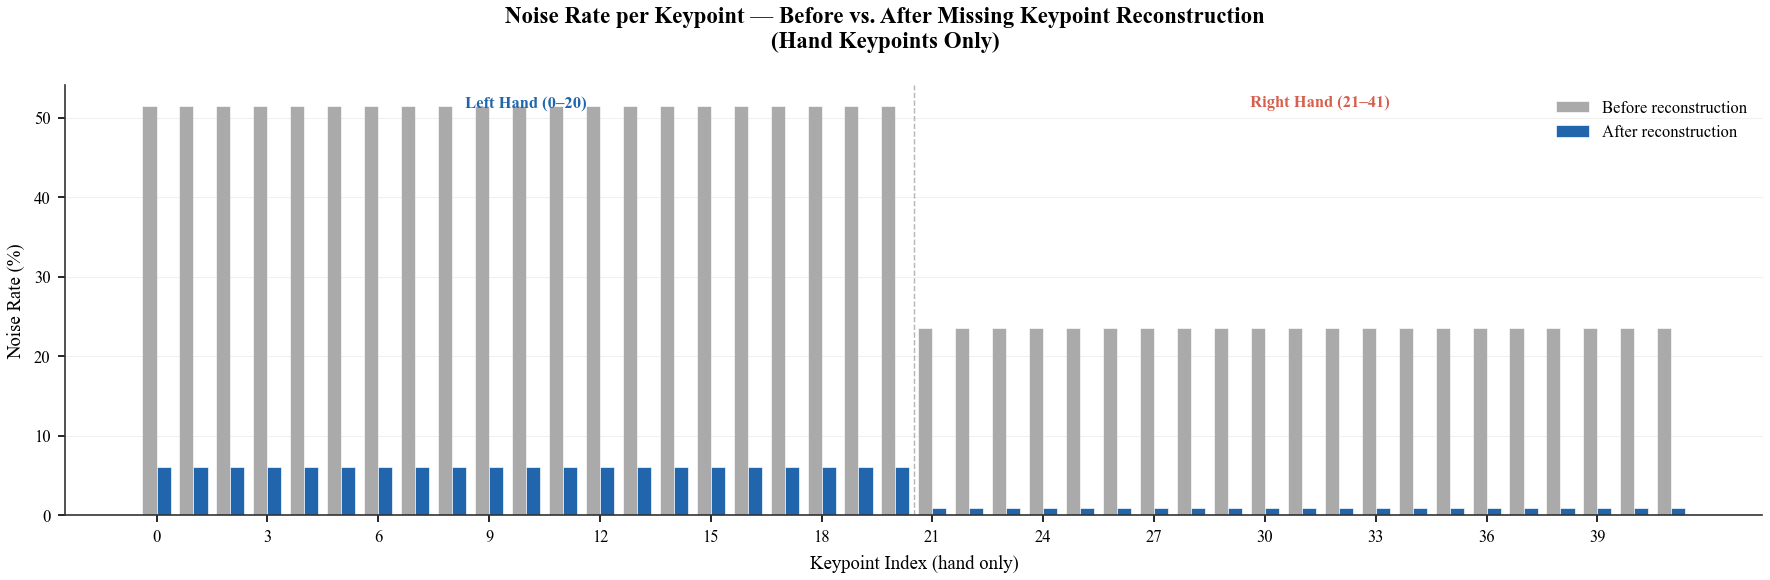

[SAVED] ../data/results\norm_D_noise_before_after.png


In [7]:
# ── Fig D: Noise Rate per Keypoint — Before vs. After Reconstruction ─────────
# Confirms that [0,0] noise is fully eliminated after reconstruction.

noise_before = np.zeros(K_TOTAL)
noise_after  = np.zeros(K_TOTAL)
total_frames = np.zeros(K_TOTAL)

for vid in video_ids:
    kp_raw = data[vid]['keypoints'].copy().astype(float)
    kp_rec = missing_keypoint_reconstruction(kp_raw)
    T = kp_raw.shape[0]

    is_noise_before = (kp_raw[:,:,0] == 0) & (kp_raw[:,:,1] == 0)
    is_noise_after  = (kp_rec[:,:,0] == 0) & (kp_rec[:,:,1] == 0)

    noise_before += is_noise_before.sum(axis=0)
    noise_after  += is_noise_after.sum(axis=0)
    total_frames += T

rate_before = noise_before / total_frames * 100
rate_after  = noise_after  / total_frames * 100

# ── Focus on hand keypoints (0-41) ────────────────────────────────────────────
x = np.arange(42)
w = 0.38

fig, ax = plt.subplots(figsize=(12, 4.0), dpi=150)

ax.bar(x - w/2, rate_before[:42], width=w,
       color=C_BEFORE, edgecolor='white', linewidth=0.3,
       label='Before reconstruction')
ax.bar(x + w/2, rate_after[:42],  width=w,
       color=C_AFTER,  edgecolor='white', linewidth=0.3,
       label='After reconstruction')

# Partition: LH | RH
ax.axvline(20.5, color='#999999', linewidth=0.7, linestyle='--', alpha=0.7)
ax.text(10,   ax.get_ylim()[1] * 0.95 if ax.get_ylim()[1] > 0 else 5,
        'Left Hand (0–20)',  ha='center', fontsize=8,
        color=C_LH, fontweight='bold')
ax.text(31.5, ax.get_ylim()[1] * 0.95 if ax.get_ylim()[1] > 0 else 5,
        'Right Hand (21–41)', ha='center', fontsize=8,
        color=C_RH, fontweight='bold')

ax.set_xlabel('Keypoint Index (hand only)')
ax.set_ylabel('Noise Rate (%)')
ax.set_xticks(np.arange(0, 42, 3))
ax.grid(axis='y', alpha=0.22, linewidth=0.4)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

ax.legend(frameon=False, fontsize=8)

plt.suptitle(
    'Noise Rate per Keypoint — Before vs. After Missing Keypoint Reconstruction\n'
    '(Hand Keypoints Only)',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()

save_path = os.path.join(OUTPUT_DIR, 'norm_D_noise_before_after.png')
plt.savefig(save_path, dpi=600)
plt.show()
print(f'[SAVED] {save_path}')

---
## IV.2.4.3 — Temporal Normalization

Two visualizations:
- **Fig E** — Sequence length distribution before vs. after temporal normalization
- **Fig F** — Coordinate trajectory before vs. after resampling (one keypoint, two example videos)


Target length (median): 194 frames


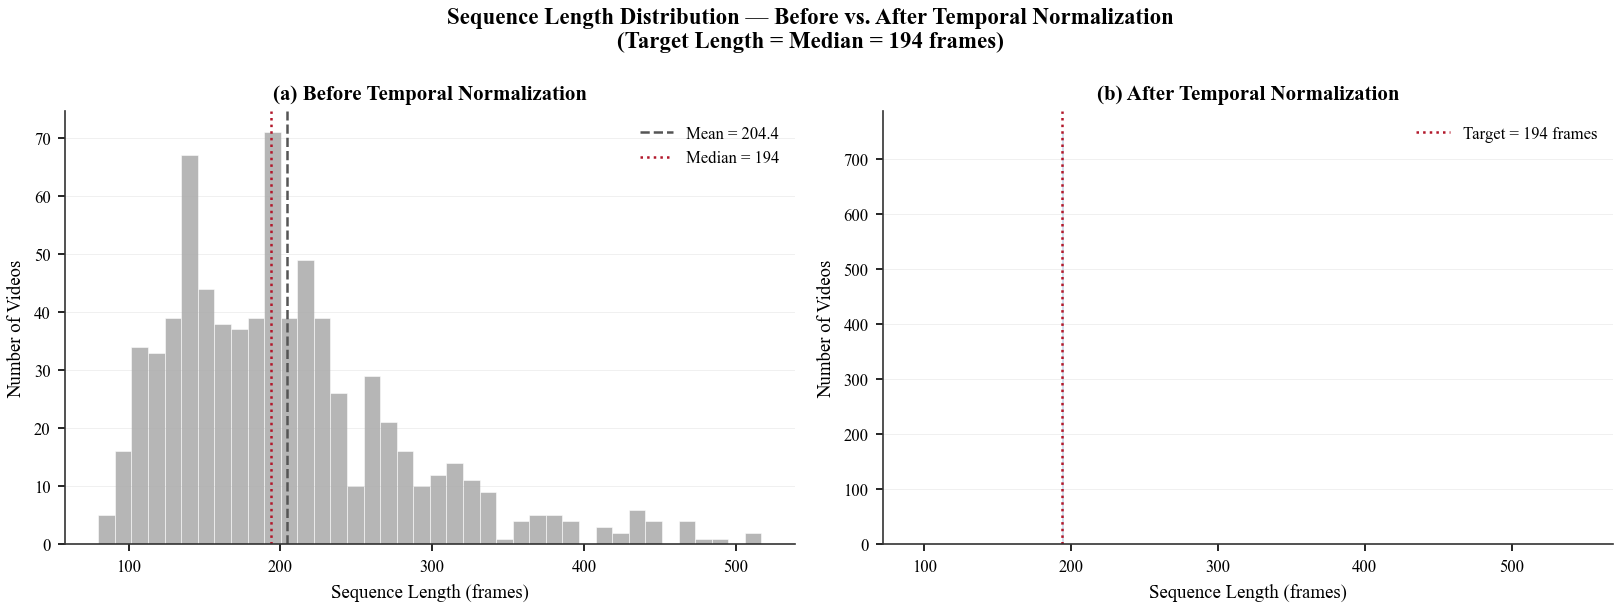

[SAVED] ../data/results\norm_E_temporal_length_before_after.png


In [8]:
# ── Fig E: Sequence Length Distribution — Before vs. After Temporal Norm ──────
# Confirms all sequences converge to target_length after normalization.

lengths_before = np.array([
    data[vid]['keypoints'].shape[0] for vid in video_ids
])

# target_length = median of the distribution (as per specification)
TARGET_LENGTH  = int(np.median(lengths_before))
print(f'Target length (median): {TARGET_LENGTH} frames')

lengths_after  = np.full(len(video_ids), TARGET_LENGTH)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), dpi=150)

# Before
axes[0].hist(lengths_before, bins=40, color=C_BEFORE,
             alpha=0.85, edgecolor='white', linewidth=0.3)
axes[0].axvline(lengths_before.mean(), color='#555555', linestyle='--',
                linewidth=1.2, label=f'Mean = {lengths_before.mean():.1f}')
axes[0].axvline(TARGET_LENGTH, color=C_MED, linestyle=':',
                linewidth=1.2, label=f'Median = {TARGET_LENGTH}')
axes[0].set_title('(a) Before Temporal Normalization')
axes[0].set_xlabel('Sequence Length (frames)')
axes[0].set_ylabel('Number of Videos')
axes[0].legend(frameon=False, fontsize=8)

# After — single spike at target_length
axes[1].hist(lengths_after, bins=1, color=C_AFTER,
             alpha=0.85, edgecolor='white', linewidth=0.3)
axes[1].axvline(TARGET_LENGTH, color=C_MED, linestyle=':',
                linewidth=1.2, label=f'Target = {TARGET_LENGTH} frames')
axes[1].set_title('(b) After Temporal Normalization')
axes[1].set_xlabel('Sequence Length (frames)')
axes[1].set_ylabel('Number of Videos')
axes[1].set_xlim(
    lengths_before.min() * 0.9,
    lengths_before.max() * 1.1
)
axes[1].legend(frameon=False, fontsize=8)

for ax in axes:
    ax.grid(axis='y', alpha=0.22, linewidth=0.4)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

plt.suptitle(
    'Sequence Length Distribution — Before vs. After Temporal Normalization\n'
    f'(Target Length = Median = {TARGET_LENGTH} frames)',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()

save_path = os.path.join(OUTPUT_DIR, 'norm_E_temporal_length_before_after.png')
plt.savefig(save_path, dpi=600)
plt.show()
print(f'[SAVED] {save_path}')

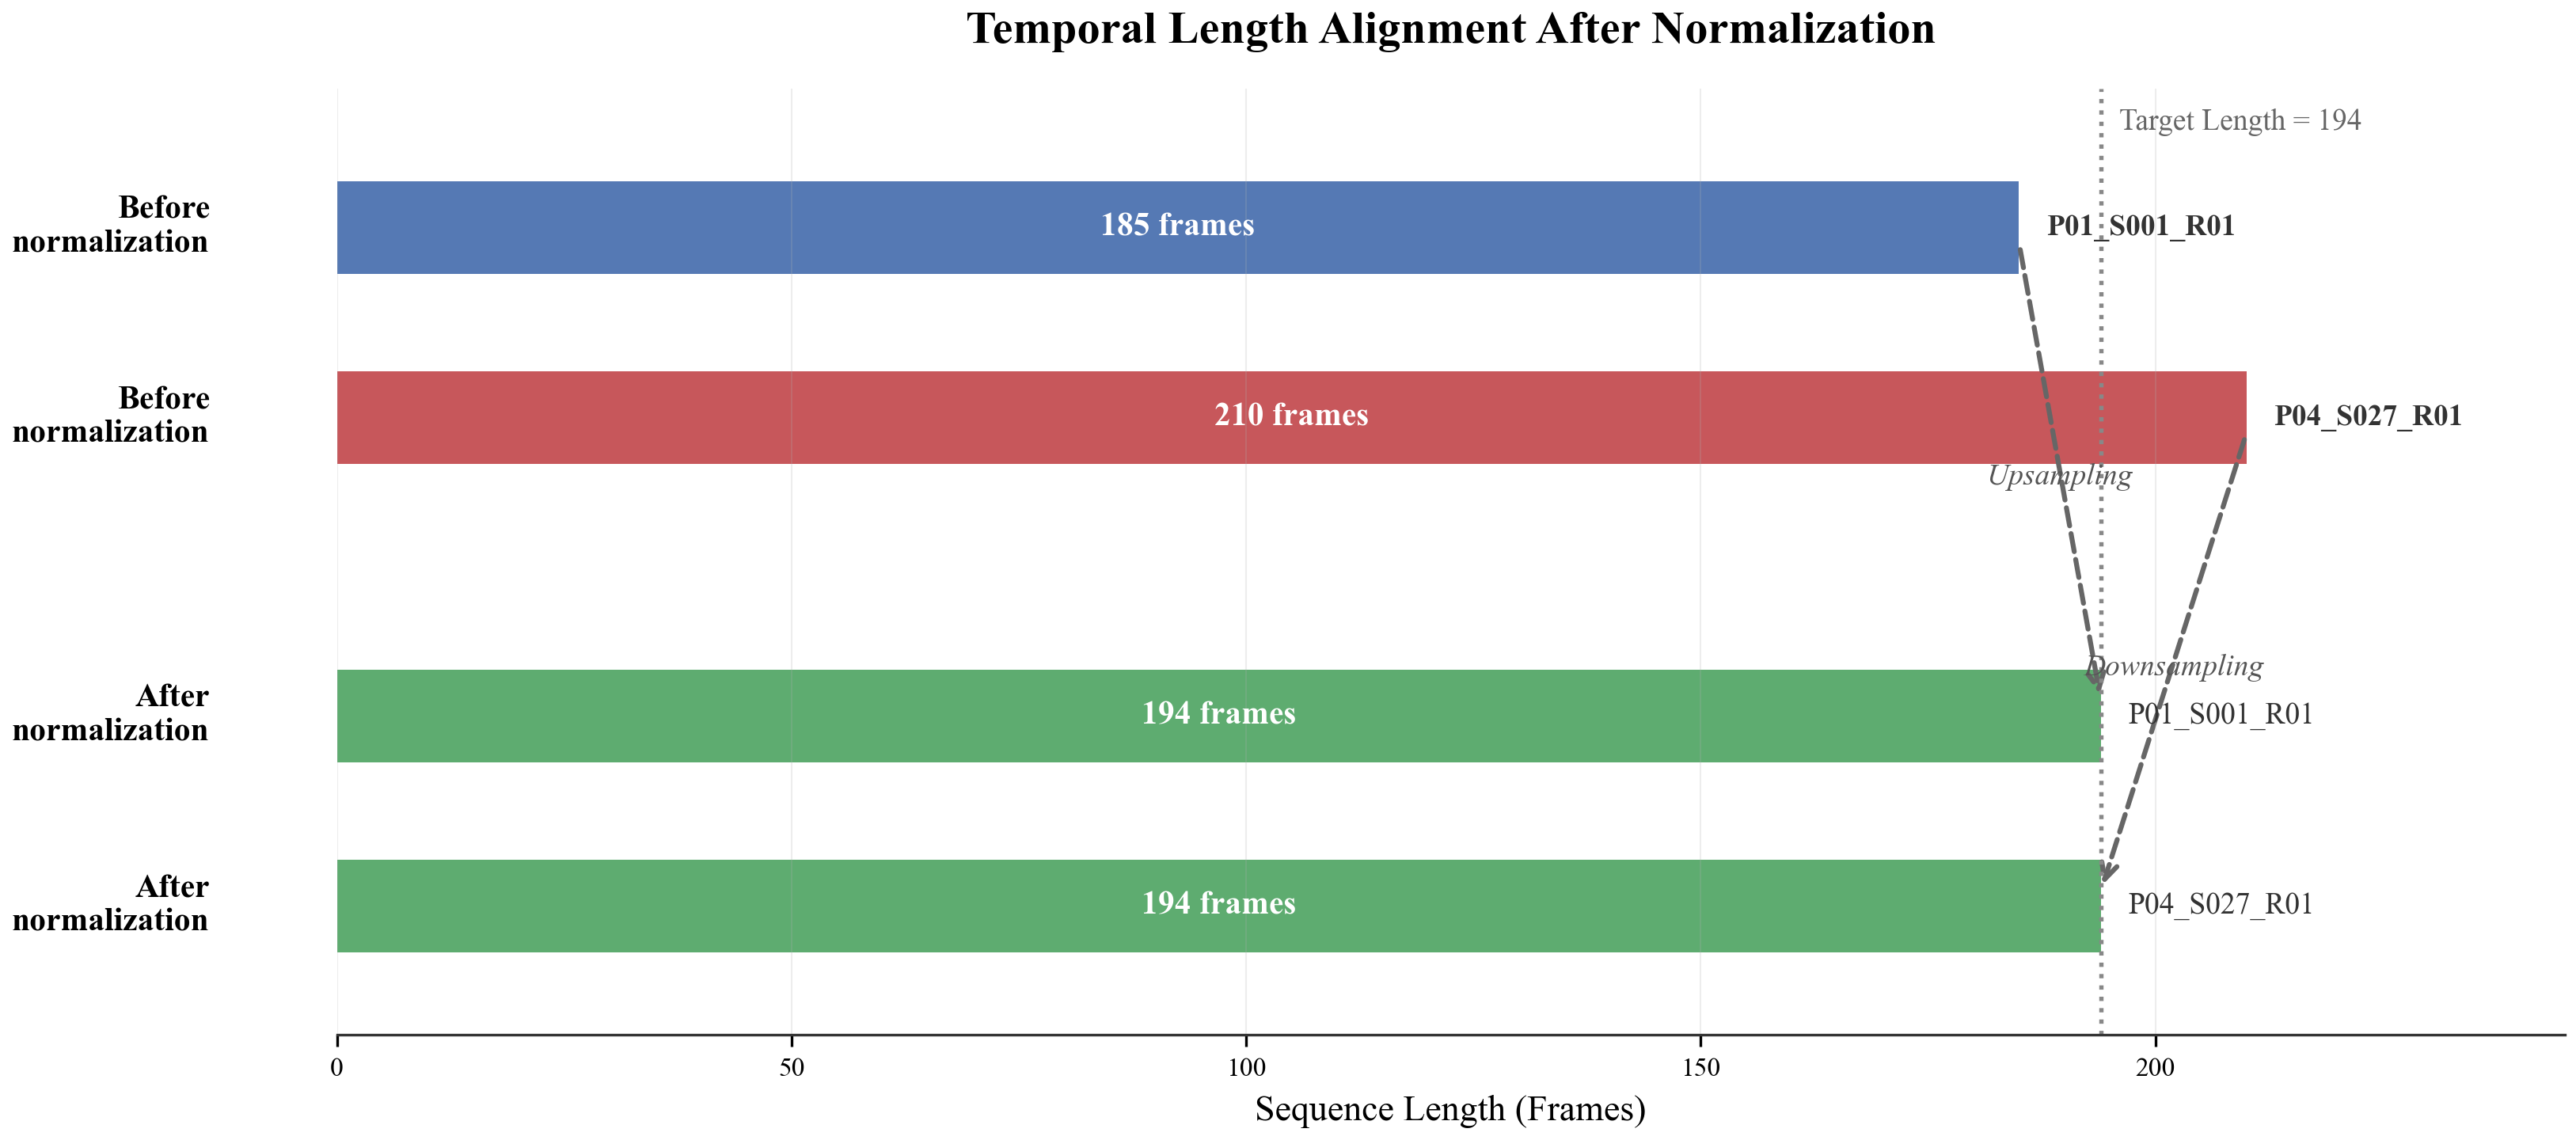

[SAVED] ../data/results\temporal_normalization_length_alignment.png


In [61]:
# ── TEMPORAL NORMALIZATION VISUALIZATION (WITH VIDEO IDs) ─────────────────
# Goal:
# Show temporal normalization effect clearly:
# - short sequence → upsampling
# - long sequence  → downsampling
# - both aligned to same target length

import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch

# ── CONFIG ─────────────────────────────────────────────────────────────────

VIDEO_SHORT = 'P01_S001_R01'
VIDEO_LONG  = 'P04_S027_R01'

TARGET = TARGET_LENGTH

SAVE_NAME = 'temporal_normalization_length_alignment.png'

# ── LOAD DATA ──────────────────────────────────────────────────────────────

kp_short = data[VIDEO_SHORT]['keypoints'].copy().astype(float)
kp_long  = data[VIDEO_LONG]['keypoints'].copy().astype(float)

len_short_before = kp_short.shape[0]
len_long_before  = kp_long.shape[0]

len_short_after = TARGET
len_long_after  = TARGET

# ── COLORS ─────────────────────────────────────────────────────────────────

C_SHORT  = '#4C72B0'
C_LONG   = '#C44E52'
C_AFTER  = '#55A868'

C_ARROW  = '#666666'

# ── FIGURE ─────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(
    figsize=(11, 5),
    dpi=300
)

# ── Y POSITIONS ────────────────────────────────────────────────────────────

y_before_short = 1.15
y_before_long  = 0.78

y_after_short  = 0.20
y_after_long   = -0.17

# ── BEFORE NORMALIZATION ──────────────────────────────────────────────────

ax.barh(
    y_before_short,
    len_short_before,
    height=0.18,
    color=C_SHORT,
    alpha=0.95
)

ax.barh(
    y_before_long,
    len_long_before,
    height=0.18,
    color=C_LONG,
    alpha=0.95
)

# ── AFTER NORMALIZATION ───────────────────────────────────────────────────

ax.barh(
    y_after_short,
    len_short_after,
    height=0.18,
    color=C_AFTER,
    alpha=0.95
)

ax.barh(
    y_after_long,
    len_long_after,
    height=0.18,
    color=C_AFTER,
    alpha=0.95
)

# ── FRAME COUNT LABELS ────────────────────────────────────────────────────

ax.text(
    len_short_before / 2,
    y_before_short,
    f'{len_short_before} frames',
    ha='center',
    va='center',
    fontsize=10,
    color='white',
    fontweight='bold'
)

ax.text(
    len_long_before / 2,
    y_before_long,
    f'{len_long_before} frames',
    ha='center',
    va='center',
    fontsize=10,
    color='white',
    fontweight='bold'
)

ax.text(
    len_short_after / 2,
    y_after_short,
    f'{len_short_after} frames',
    ha='center',
    va='center',
    fontsize=10,
    color='white',
    fontweight='bold'
)

ax.text(
    len_long_after / 2,
    y_after_long,
    f'{len_long_after} frames',
    ha='center',
    va='center',
    fontsize=10,
    color='white',
    fontweight='bold'
)

# ── VIDEO ID LABELS ────────────────────────────────────────────────────────

ax.text(
    len_short_before + 3,
    y_before_short,
    VIDEO_SHORT,
    fontsize=9,
    va='center',
    color='#333333',
    fontweight='semibold'
)

ax.text(
    len_long_before + 3,
    y_before_long,
    VIDEO_LONG,
    fontsize=9,
    va='center',
    color='#333333',
    fontweight='semibold'
)

ax.text(
    len_short_after + 3,
    y_after_short,
    VIDEO_SHORT,
    fontsize=9,
    va='center',
    color='#333333'
)

ax.text(
    len_long_after + 3,
    y_after_long,
    VIDEO_LONG,
    fontsize=9,
    va='center',
    color='#333333'
)

# ── LEFT LABELS ────────────────────────────────────────────────────────────

ax.text(
    -14,
    y_before_short,
    'Before\nnormalization',
    ha='right',
    va='center',
    fontsize=10,
    fontweight='semibold'
)

ax.text(
    -14,
    y_before_long,
    'Before\nnormalization',
    ha='right',
    va='center',
    fontsize=10,
    fontweight='semibold'
)

ax.text(
    -14,
    y_after_short,
    'After\nnormalization',
    ha='right',
    va='center',
    fontsize=10,
    fontweight='semibold'
)

ax.text(
    -14,
    y_after_long,
    'After\nnormalization',
    ha='right',
    va='center',
    fontsize=10,
    fontweight='semibold'
)

# ── ARROWS ─────────────────────────────────────────────────────────────────

arrow_up = FancyArrowPatch(
    (len_short_before, y_before_short - 0.03),
    (len_short_after, y_after_short + 0.03),
    arrowstyle='->',
    mutation_scale=12,
    linewidth=1.5,
    linestyle='--',
    color=C_ARROW
)

arrow_down = FancyArrowPatch(
    (len_long_before, y_before_long - 0.03),
    (len_long_after, y_after_long + 0.03),
    arrowstyle='->',
    mutation_scale=12,
    linewidth=1.5,
    linestyle='--',
    color=C_ARROW
)

ax.add_patch(arrow_up)
ax.add_patch(arrow_down)

# ── OPERATION LABELS ───────────────────────────────────────────────────────

ax.text(
    (len_short_before + len_short_after) / 2,
    0.65,
    'Upsampling',
    fontsize=9,
    style='italic',
    ha='center',
    color='#555555'
)

ax.text(
    (len_long_before + len_long_after) / 2,
    0.28,
    'Downsampling',
    fontsize=9,
    style='italic',
    ha='center',
    color='#555555'
)

# ── TARGET INDICATOR ───────────────────────────────────────────────────────

ax.axvline(
    TARGET,
    linestyle=':',
    linewidth=1.3,
    color='#888888'
)

ax.text(
    TARGET + 2,
    1.34,
    f'Target Length = {TARGET}',
    fontsize=9,
    color='#666666'
)

# ── STYLE ──────────────────────────────────────────────────────────────────

ax.set_xlim(0, max(len_long_before, TARGET) + 35)

ax.set_ylim(-0.42, 1.42)

ax.set_yticks([])

ax.set_xlabel(
    'Sequence Length (Frames)',
    fontsize=11
)

ax.set_title(
    'Temporal Length Alignment After Normalization',
    fontsize=14,
    fontweight='bold',
    pad=14
)

ax.grid(
    axis='x',
    alpha=0.22,
    linewidth=0.5
)

for spine in ['top', 'right', 'left']:

    ax.spines[spine].set_visible(False)

# ── SAVE ───────────────────────────────────────────────────────────────────

save_path = os.path.join(
    OUTPUT_DIR,
    SAVE_NAME
)

plt.tight_layout()

plt.savefig(
    save_path,
    dpi=600,
    bbox_inches='tight',
    facecolor='white'
)

plt.show()

print(f'[SAVED] {save_path}')

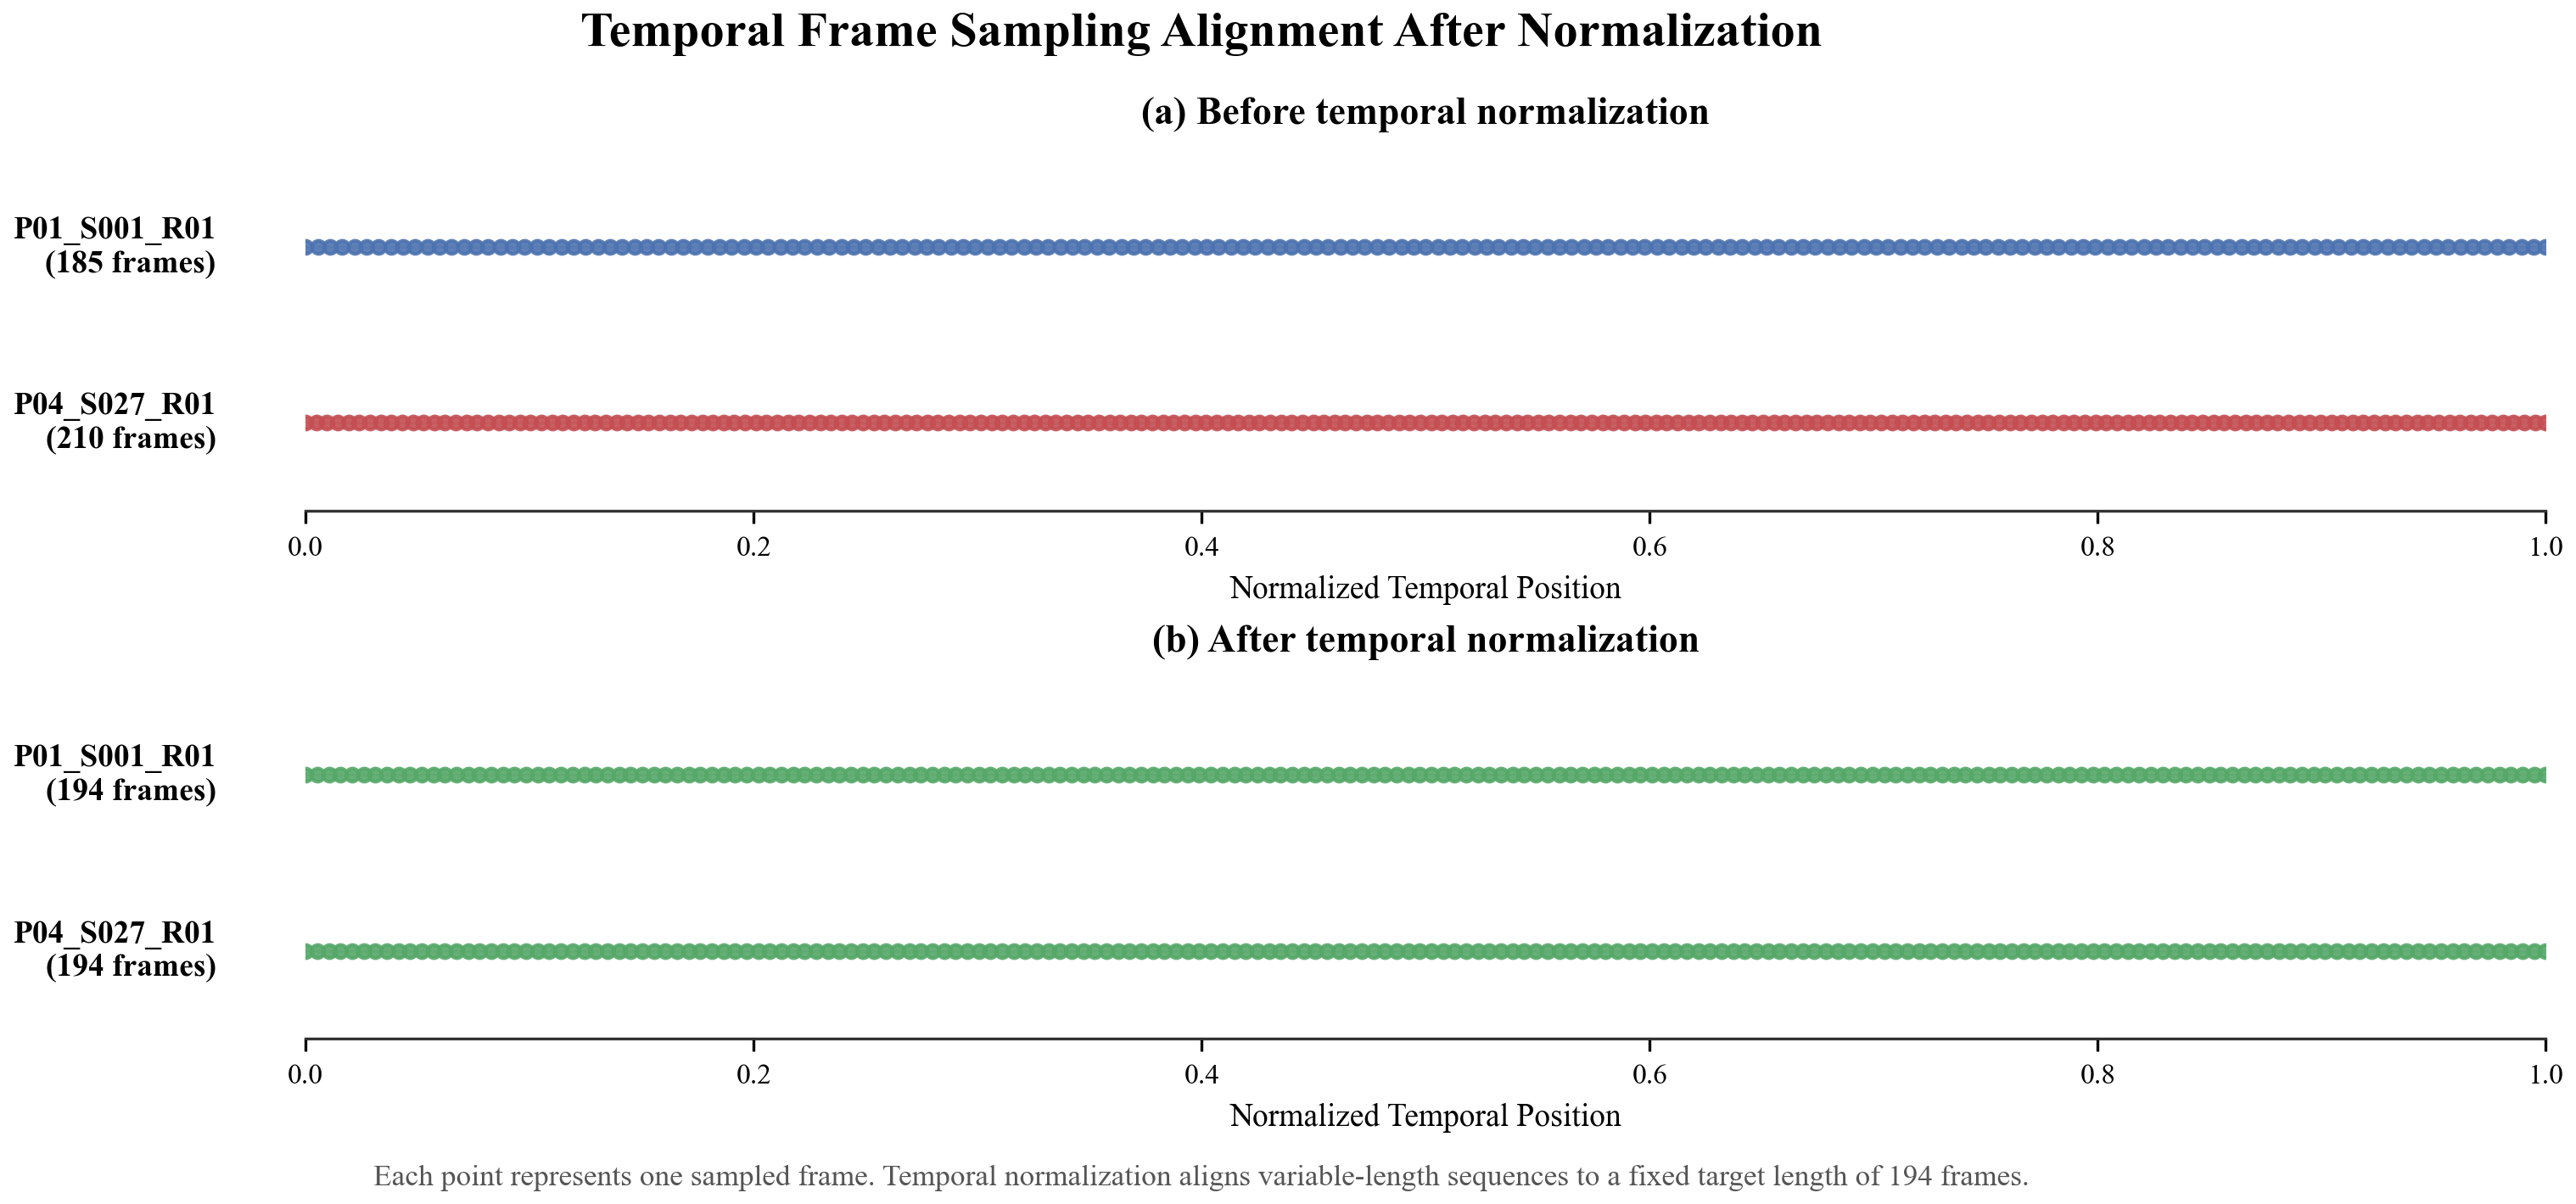

[SAVED] ../data/results\temporal_sampling_alignment.png


In [63]:
# ── TEMPORAL SAMPLING VISUALIZATION ───────────────────────────────────────
# Goal:
# Clearly visualize temporal normalization by showing:
# - inconsistent frame sampling before normalization
# - aligned temporal sampling after normalization
#
# Each dot represents one sampled frame.

import os
import numpy as np
import matplotlib.pyplot as plt

# ── CONFIG ─────────────────────────────────────────────────────────────────

VIDEO_SHORT = 'P01_S001_R01'
VIDEO_LONG  = 'P04_S027_R01'

TARGET = TARGET_LENGTH

SAVE_NAME = 'temporal_sampling_alignment.png'

# ── LOAD DATA ──────────────────────────────────────────────────────────────

kp_short = data[VIDEO_SHORT]['keypoints'].copy().astype(float)
kp_long  = data[VIDEO_LONG]['keypoints'].copy().astype(float)

len_short_before = kp_short.shape[0]
len_long_before  = kp_long.shape[0]

len_short_after = TARGET
len_long_after  = TARGET

# ── TEMPORAL POSITIONS ────────────────────────────────────────────────────

t_short_before = np.linspace(0, 1, len_short_before)
t_long_before  = np.linspace(0, 1, len_long_before)

t_short_after = np.linspace(0, 1, len_short_after)
t_long_after  = np.linspace(0, 1, len_long_after)

# ── COLORS ─────────────────────────────────────────────────────────────────

C_SHORT  = '#4C72B0'
C_LONG   = '#C44E52'
C_AFTER  = '#55A868'

# ── FIGURE ─────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(
    2,
    1,
    figsize=(11, 4.8),
    dpi=300
)

# =============================================================================
# BEFORE NORMALIZATION
# =============================================================================

ax = axes[0]

# short sequence
ax.scatter(
    t_short_before,
    np.ones_like(t_short_before) * 1,
    s=14,
    color=C_SHORT,
    alpha=0.9
)

# long sequence
ax.scatter(
    t_long_before,
    np.ones_like(t_long_before) * 0,
    s=14,
    color=C_LONG,
    alpha=0.9
)

# labels
ax.text(
    -0.04,
    1,
    f'{VIDEO_SHORT}\n({len_short_before} frames)',
    ha='right',
    va='center',
    fontsize=9,
    fontweight='semibold'
)

ax.text(
    -0.04,
    0,
    f'{VIDEO_LONG}\n({len_long_before} frames)',
    ha='right',
    va='center',
    fontsize=9,
    fontweight='semibold'
)

# title
ax.set_title(
    '(a) Before temporal normalization',
    fontsize=11,
    fontweight='semibold',
    pad=10
)

# =============================================================================
# AFTER NORMALIZATION
# =============================================================================

ax = axes[1]

# normalized short
ax.scatter(
    t_short_after,
    np.ones_like(t_short_after) * 1,
    s=14,
    color=C_AFTER,
    alpha=0.9
)

# normalized long
ax.scatter(
    t_long_after,
    np.ones_like(t_long_after) * 0,
    s=14,
    color=C_AFTER,
    alpha=0.9
)

# labels
ax.text(
    -0.04,
    1,
    f'{VIDEO_SHORT}\n({len_short_after} frames)',
    ha='right',
    va='center',
    fontsize=9,
    fontweight='semibold'
)

ax.text(
    -0.04,
    0,
    f'{VIDEO_LONG}\n({len_long_after} frames)',
    ha='right',
    va='center',
    fontsize=9,
    fontweight='semibold'
)

# title
ax.set_title(
    '(b) After temporal normalization',
    fontsize=11,
    fontweight='semibold',
    pad=10
)

# =============================================================================
# STYLE
# =============================================================================

for ax in axes:

    # guide lines
    ax.hlines(
        [0, 1],
        xmin=0,
        xmax=1,
        colors='#D8D8D8',
        linewidth=0.8,
        zorder=0
    )

    ax.set_xlim(0, 1)

    ax.set_ylim(-0.5, 1.5)

    ax.set_yticks([])

    ax.set_xlabel(
        'Normalized Temporal Position',
        fontsize=9
    )

    # remove unnecessary borders
    for spine in ['top', 'right', 'left']:

        ax.spines[spine].set_visible(False)

# ── SUPTITLE ───────────────────────────────────────────────────────────────

plt.suptitle(
    'Temporal Frame Sampling Alignment After Normalization',
    fontsize=14,
    fontweight='bold',
    y=0.98
)

# ── EXPLANATION TEXT ───────────────────────────────────────────────────────

fig.text(
    0.5,
    0.02,
    (
        'Each point represents one sampled frame. '
        'Temporal normalization aligns variable-length sequences '
        f'to a fixed target length of {TARGET} frames.'
    ),
    ha='center',
    fontsize=8.5,
    color='#555555'
)

# ── LAYOUT ─────────────────────────────────────────────────────────────────

plt.subplots_adjust(
    left=0.18,
    right=0.98,
    top=0.86,
    bottom=0.14,
    hspace=0.5
)

# ── SAVE ───────────────────────────────────────────────────────────────────

save_path = os.path.join(
    OUTPUT_DIR,
    SAVE_NAME
)

plt.savefig(
    save_path,
    dpi=600,
    bbox_inches='tight',
    facecolor='white'
)

plt.show()

print(f'[SAVED] {save_path}')

---
## Summary — Output Files


In [10]:
print('='*65)
print('  OUTPUT SUMMARY — IV.2.4 Normalization Analysis')
print('='*65)
outputs = [
    ('norm_A_spatial_scatter_before_after.png',
     'IV.2.4.1 — Scatter overlay before/after spatial normalization (all signers)'),
    ('norm_B_skeleton_raw_vs_normalized.png',
     'IV.2.4.1 — Skeleton frame: raw vs. spatially normalized'),
    ('norm_C_reconstruction_trajectory.png',
     'IV.2.4.2 — Coordinate trajectory before/after missing keypoint reconstruction'),
    ('norm_D_noise_before_after.png',
     'IV.2.4.2 — Noise rate per keypoint before/after reconstruction'),
    ('norm_E_temporal_length_before_after.png',
     'IV.2.4.3 — Sequence length distribution before/after temporal normalization'),
    ('norm_F_temporal_trajectory_before_after.png',
     'IV.2.4.3 — Coordinate trajectory before/after temporal resampling'),
]
for fname, desc in outputs:
    path   = os.path.join(OUTPUT_DIR, fname)
    status = '[OK]' if os.path.exists(path) else '[--]'
    print(f'  {status}  {fname}')
    print(f'         → {desc}')
print('='*65)

  OUTPUT SUMMARY — IV.2.4 Normalization Analysis
  [OK]  norm_A_spatial_scatter_before_after.png
         → IV.2.4.1 — Scatter overlay before/after spatial normalization (all signers)
  [OK]  norm_B_skeleton_raw_vs_normalized.png
         → IV.2.4.1 — Skeleton frame: raw vs. spatially normalized
  [OK]  norm_C_reconstruction_trajectory.png
         → IV.2.4.2 — Coordinate trajectory before/after missing keypoint reconstruction
  [OK]  norm_D_noise_before_after.png
         → IV.2.4.2 — Noise rate per keypoint before/after reconstruction
  [OK]  norm_E_temporal_length_before_after.png
         → IV.2.4.3 — Sequence length distribution before/after temporal normalization
  [OK]  norm_F_temporal_trajectory_before_after.png
         → IV.2.4.3 — Coordinate trajectory before/after temporal resampling
